# Sleep Apnea Detection Using Machine Learning: A Comprehensive Clinical Study

In [1]:
# =========================
# BLOCK 1: Imports and Configuration
# =========================
import os, gc, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter

# Sklearn core
from sklearn.model_selection import (
    StratifiedKFold, train_test_split, 
    cross_validate, cross_val_predict
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    classification_report, make_scorer
)

# Imbalance handling
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

# Optional advanced libraries
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️ XGBoost not available. Using GradientBoosting instead.")

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️ SHAP not available. Feature importance will be used instead.")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


In [2]:
# =========================
# BLOCK 2: Robust Data Loading
# =========================

def find_csv_in_kaggle_input(keyword: str):
    """Find CSV files in Kaggle input directory by keyword."""
    if not os.path.exists("/kaggle/input"):
        return None
    
    candidates = glob.glob("/kaggle/input/**/*.csv", recursive=True)
    keyword = keyword.lower()
    for p in candidates:
        if keyword in os.path.basename(p).lower():
            return p
    return None

def load_datasets():
    """Load both lifestyle and diagnostic datasets with robust path detection."""
    print("📂 Loading datasets...")
    
    # Try exact paths first
    known_paths = {
        'life': "/kaggle/input/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv",
        'diag': "/kaggle/input/sleep-disorder-diagnostic-dataset/sleep_disorder_dataset.csv"
    }
    
    life_path = known_paths['life'] if os.path.exists(known_paths['life']) else None
    diag_path = known_paths['diag'] if os.path.exists(known_paths['diag']) else None
    
    # Fallback: search by keyword
    if life_path is None:
        life_path = find_csv_in_kaggle_input("lifestyle") or find_csv_in_kaggle_input("health")
    if diag_path is None:
        diag_path = find_csv_in_kaggle_input("disorder") or find_csv_in_kaggle_input("diagnostic")
    
    if life_path is None or diag_path is None:
        raise FileNotFoundError(
            "❌ Could not locate datasets. Please check /kaggle/input structure.\n"
            "Available CSVs: " + str(glob.glob("/kaggle/input/**/*.csv", recursive=True)[:10])
        )
    
    print(f"✅ Lifestyle dataset: {life_path}")
    print(f"✅ Diagnostic dataset: {diag_path}")
    
    df_life = pd.read_csv(life_path)
    df_diag = pd.read_csv(diag_path)
    
    print(f"\n📊 Lifestyle shape: {df_life.shape}")
    print(f"📊 Diagnostic shape: {df_diag.shape}")
    
    return df_life, df_diag

# Load data
df_life_raw, df_diag_raw = load_datasets()

print("\n📋 Lifestyle Dataset Sample:")
display(df_life_raw.head(3))

print("\n📋 Diagnostic Dataset Sample:")
display(df_diag_raw.head(3))

📂 Loading datasets...
✅ Lifestyle dataset: /kaggle/input/datasets/uom190346a/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv
✅ Diagnostic dataset: /kaggle/input/datasets/ziya07/sleep-disorder-diagnostic-dataset/sleep_disorder_dataset.csv

📊 Lifestyle shape: (374, 13)
📊 Diagnostic shape: (1000, 8)

📋 Lifestyle Dataset Sample:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN



📋 Diagnostic Dataset Sample:


,Patient_ID,Age,Gender,Sleep_Disorder_Type,AHI_Score,SaO2_Level,OCR_Extracted_Text,Diagnosis_Confirmed
0,P0001,54,Female,Restless Leg Syndrome,44.11,77.59,Patient P0001 diagnosed with Restless Leg Synd...,1
1,P0002,17,Female,Restless Leg Syndrome,33.55,76.22,Patient P0002 diagnosed with Restless Leg Synd...,1
2,P0003,74,Male,Insomnia,12.91,89.53,Patient P0003 diagnosed with Insomnia.,1


In [3]:
# =========================
# BLOCK 3: Data Cleaning and Preprocessing
# =========================

def clean_clinical_data(df, source_name):
    """Standardize column names and clean text fields."""
    df = df.copy()
    
    # Standardize column names
    df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')
    
    # Clean text columns
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace(['nan', 'None', 'NaN', ''], np.nan)
    
    # Add source identifier
    df['Source'] = source_name
    
    return df

# Clean both datasets
df_life = clean_clinical_data(df_life_raw, 'Lifestyle')
df_diag = clean_clinical_data(df_diag_raw, 'Diagnostic')

print("✅ Data cleaning complete")
print(f"\nLifestyle columns: {list(df_life.columns)}")
print(f"\nDiagnostic columns: {list(df_diag.columns)}")

✅ Data cleaning complete

Lifestyle columns: ['Person_ID', 'Gender', 'Age', 'Occupation', 'Sleep_Duration', 'Quality_of_Sleep', 'Physical_Activity_Level', 'Stress_Level', 'BMI_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps', 'Sleep_Disorder', 'Source']

Diagnostic columns: ['Patient_ID', 'Age', 'Gender', 'Sleep_Disorder_Type', 'AHI_Score', 'SaO2_Level', 'OCR_Extracted_Text', 'Diagnosis_Confirmed', 'Source']


In [4]:
# =========================
# BLOCK 4: Target Variable Creation (Robust)
# =========================

def create_apnea_target(x):
    """Convert disorder labels to binary apnea indicator."""
    if pd.isna(x):
        return 0
    
    x_str = str(x).strip().lower()
    
    # Positive indicators
    positive_terms = ['apnea', 'sleep apnea', 'osa', 'obstructive']
    if any(term in x_str for term in positive_terms):
        return 1
    
    # Negative indicators
    negative_terms = ['none', 'normal', 'no', 'healthy', '0']
    if x_str in negative_terms:
        return 0
    
    # For numeric values
    try:
        val = float(x_str)
        return int(val > 0)
    except ValueError:
        # Default: if contains 'insomnia' or other disorders, mark as 0 for apnea
        return 0

# Process Lifestyle dataset
life_label_cols = [c for c in df_life.columns 
                   if any(k in c.lower() for k in ['disorder', 'diagnosis', 'condition'])]

if life_label_cols:
    df_life['Apnea_Target'] = df_life[life_label_cols[0]].apply(create_apnea_target)
    print(f"✅ Lifestyle label from: {life_label_cols[0]}")
else:
    df_life['Apnea_Target'] = 0
    print("⚠️ No disorder column in lifestyle data, setting all to 0")

# Process Diagnostic dataset
diag_label_cols = [c for c in df_diag.columns 
                   if any(k in c.lower() for k in ['label', 'target', 'disorder', 'diagnosis', 'confirmed'])]

if diag_label_cols:
    df_diag['Apnea_Target'] = df_diag[diag_label_cols[0]].apply(create_apnea_target)
    print(f"✅ Diagnostic label from: {diag_label_cols[0]}")
else:
    raise ValueError("❌ No label column found in diagnostic dataset")

# Display target distribution
print("\n📊 Target Distribution:")
print("\nLifestyle:")
print(df_life['Apnea_Target'].value_counts())
print(f"Prevalence: {df_life['Apnea_Target'].mean():.2%}")

print("\nDiagnostic:")
print(df_diag['Apnea_Target'].value_counts())
print(f"Prevalence: {df_diag['Apnea_Target'].mean():.2%}")

✅ Lifestyle label from: Sleep_Disorder
✅ Diagnostic label from: Sleep_Disorder_Type

📊 Target Distribution:

Lifestyle:
Apnea_Target
0    296
1     78
Name: count, dtype: int64
Prevalence: 20.86%

Diagnostic:
Apnea_Target
0    691
1    309
Name: count, dtype: int64
Prevalence: 30.90%


In [5]:
# =========================
# BLOCK 5: Advanced Feature Engineering
# =========================

def engineer_clinical_features(df):
    """Create clinically-relevant derived features."""
    df = df.copy()
    
    # 1. Blood Pressure Markers
    if 'Blood_Pressure' in df.columns:
        bp_split = df['Blood_Pressure'].astype(str).str.split('/', expand=True)
        if bp_split.shape[1] >= 2:
            df['Systolic_BP'] = pd.to_numeric(bp_split[0], errors='coerce')
            df['Diastolic_BP'] = pd.to_numeric(bp_split[1], errors='coerce')
            
            # Mean Arterial Pressure: (2*DBP + SBP) / 3
            df['MAP'] = (2 * df['Diastolic_BP'] + df['Systolic_BP']) / 3
            
            # Pulse Pressure: SBP - DBP (indicator of arterial stiffness)
            df['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']
            
            # Hypertension indicator
            df['Hypertension'] = ((df['Systolic_BP'] >= 140) | 
                                  (df['Diastolic_BP'] >= 90)).astype(int)
    
    # 2. Sleep Quality Metrics
    if 'Sleep_Duration' in df.columns and 'Quality_of_Sleep' in df.columns:
        # Sleep efficiency index
        df['Sleep_Efficiency'] = (df['Sleep_Duration'] * df['Quality_of_Sleep']) / 10
        
        # Sleep deprivation indicator (<6 hours)
        df['Sleep_Deprived'] = (df['Sleep_Duration'] < 6).astype(int)
        
        # Poor sleep quality indicator
        df['Poor_Sleep_Quality'] = (df['Quality_of_Sleep'] <= 5).astype(int)
    
    # 3. BMI Category (if BMI exists)
    if 'BMI_Category' in df.columns:
        bmi_map = {
            'Underweight': 0, 'Normal': 1, 'Normal Weight': 1,
            'Overweight': 2, 'Obese': 3, 'Obesity': 3
        }
        df['BMI_Numeric'] = df['BMI_Category'].map(bmi_map)
    
    # 4. Age Groups (clinical relevance)
    if 'Age' in df.columns:
        df['Age_Group'] = pd.cut(
            df['Age'], 
            bins=[0, 35, 50, 65, 100], 
            labels=['Young', 'Middle_Aged', 'Senior', 'Elderly']
        )
        
        # Age squared (non-linear relationship)
        df['Age_Squared'] = df['Age'] ** 2
    
    # 5. Activity-Stress Interaction
    if 'Physical_Activity_Level' in df.columns and 'Stress_Level' in df.columns:
        df['Activity_Stress_Ratio'] = df['Physical_Activity_Level'] / (df['Stress_Level'] + 1)
        df['High_Stress_Low_Activity'] = ((df['Stress_Level'] >= 7) & 
                                          (df['Physical_Activity_Level'] <= 30)).astype(int)
    
    # 6. Cardiovascular Risk Score
    if all(c in df.columns for c in ['Heart_Rate', 'MAP']):
        # Normalized composite score
        hr_norm = (df['Heart_Rate'] - 60) / 20  # normalize around 60-80 bpm
        map_norm = (df['MAP'] - 93) / 10  # normalize around 93 mmHg
        df['CV_Risk_Score'] = hr_norm + map_norm
    
    # 7. Gender encoding (if exists)
    if 'Gender' in df.columns:
        df['Gender_Male'] = (df['Gender'].str.lower() == 'male').astype(int)
    
    return df

# Apply feature engineering
df_life_eng = engineer_clinical_features(df_life)
df_diag_eng = engineer_clinical_features(df_diag)

print("✅ Feature engineering complete")
print(f"\nNew features in Lifestyle: {set(df_life_eng.columns) - set(df_life.columns)}")
print(f"New features in Diagnostic: {set(df_diag_eng.columns) - set(df_diag.columns)}")

✅ Feature engineering complete

New features in Lifestyle: {'Hypertension', 'Diastolic_BP', 'High_Stress_Low_Activity', 'Age_Squared', 'BMI_Numeric', 'MAP', 'Poor_Sleep_Quality', 'Activity_Stress_Ratio', 'Pulse_Pressure', 'Systolic_BP', 'Sleep_Efficiency', 'Sleep_Deprived', 'CV_Risk_Score', 'Gender_Male', 'Age_Group'}
New features in Diagnostic: {'Age_Group', 'Age_Squared', 'Gender_Male'}


In [6]:
# =========================
# BLOCK 6: Dataset Merging and Feature Selection
# =========================

# Define core feature set (present in both datasets)
core_features = [
    # Demographics
    'Age', 'Gender_Male',
    
    # Sleep metrics
    'Sleep_Duration', 'Quality_of_Sleep', 'Sleep_Efficiency',
    'Sleep_Deprived', 'Poor_Sleep_Quality',
    
    # Lifestyle
    'Physical_Activity_Level', 'Stress_Level', 'Daily_Steps',
    'Activity_Stress_Ratio', 'High_Stress_Low_Activity',
    
    # Cardiovascular
    'Heart_Rate', 'Systolic_BP', 'Diastolic_BP', 
    'MAP', 'Pulse_Pressure', 'Hypertension', 'CV_Risk_Score',
    
    # BMI
    'BMI_Numeric',
    
    # Non-linear
    'Age_Squared'
]

def align_features(df, feature_list):
    """Ensure all required features exist, filling with NaN if missing."""
    for feat in feature_list:
        if feat not in df.columns:
            df[feat] = np.nan
    return df[feature_list + ['Apnea_Target', 'Source']]

# Align both datasets
df_life_aligned = align_features(df_life_eng, core_features)
df_diag_aligned = align_features(df_diag_eng, core_features)

# Merge datasets
df_merged = pd.concat([df_life_aligned, df_diag_aligned], axis=0, ignore_index=True)

print(f"✅ Merged dataset shape: {df_merged.shape}")
print(f"\n📊 Class distribution in merged data:")
print(df_merged['Apnea_Target'].value_counts())
print(f"Overall prevalence: {df_merged['Apnea_Target'].mean():.2%}")

print(f"\n📊 Missing value summary:")
missing_pct = (df_merged.isnull().sum() / len(df_merged) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

✅ Merged dataset shape: (1374, 23)

📊 Class distribution in merged data:
Apnea_Target
0    987
1    387
Name: count, dtype: int64
Overall prevalence: 28.17%

📊 Missing value summary:
Sleep_Duration              72.780204
Sleep_Efficiency            72.780204
Quality_of_Sleep            72.780204
Sleep_Deprived              72.780204
Poor_Sleep_Quality          72.780204
Stress_Level                72.780204
Physical_Activity_Level     72.780204
MAP                         72.780204
Pulse_Pressure              72.780204
Daily_Steps                 72.780204
Activity_Stress_Ratio       72.780204
High_Stress_Low_Activity    72.780204
Heart_Rate                  72.780204
Systolic_BP                 72.780204
Diastolic_BP                72.780204
BMI_Numeric                 72.780204
CV_Risk_Score               72.780204
Hypertension                72.780204
dtype: float64


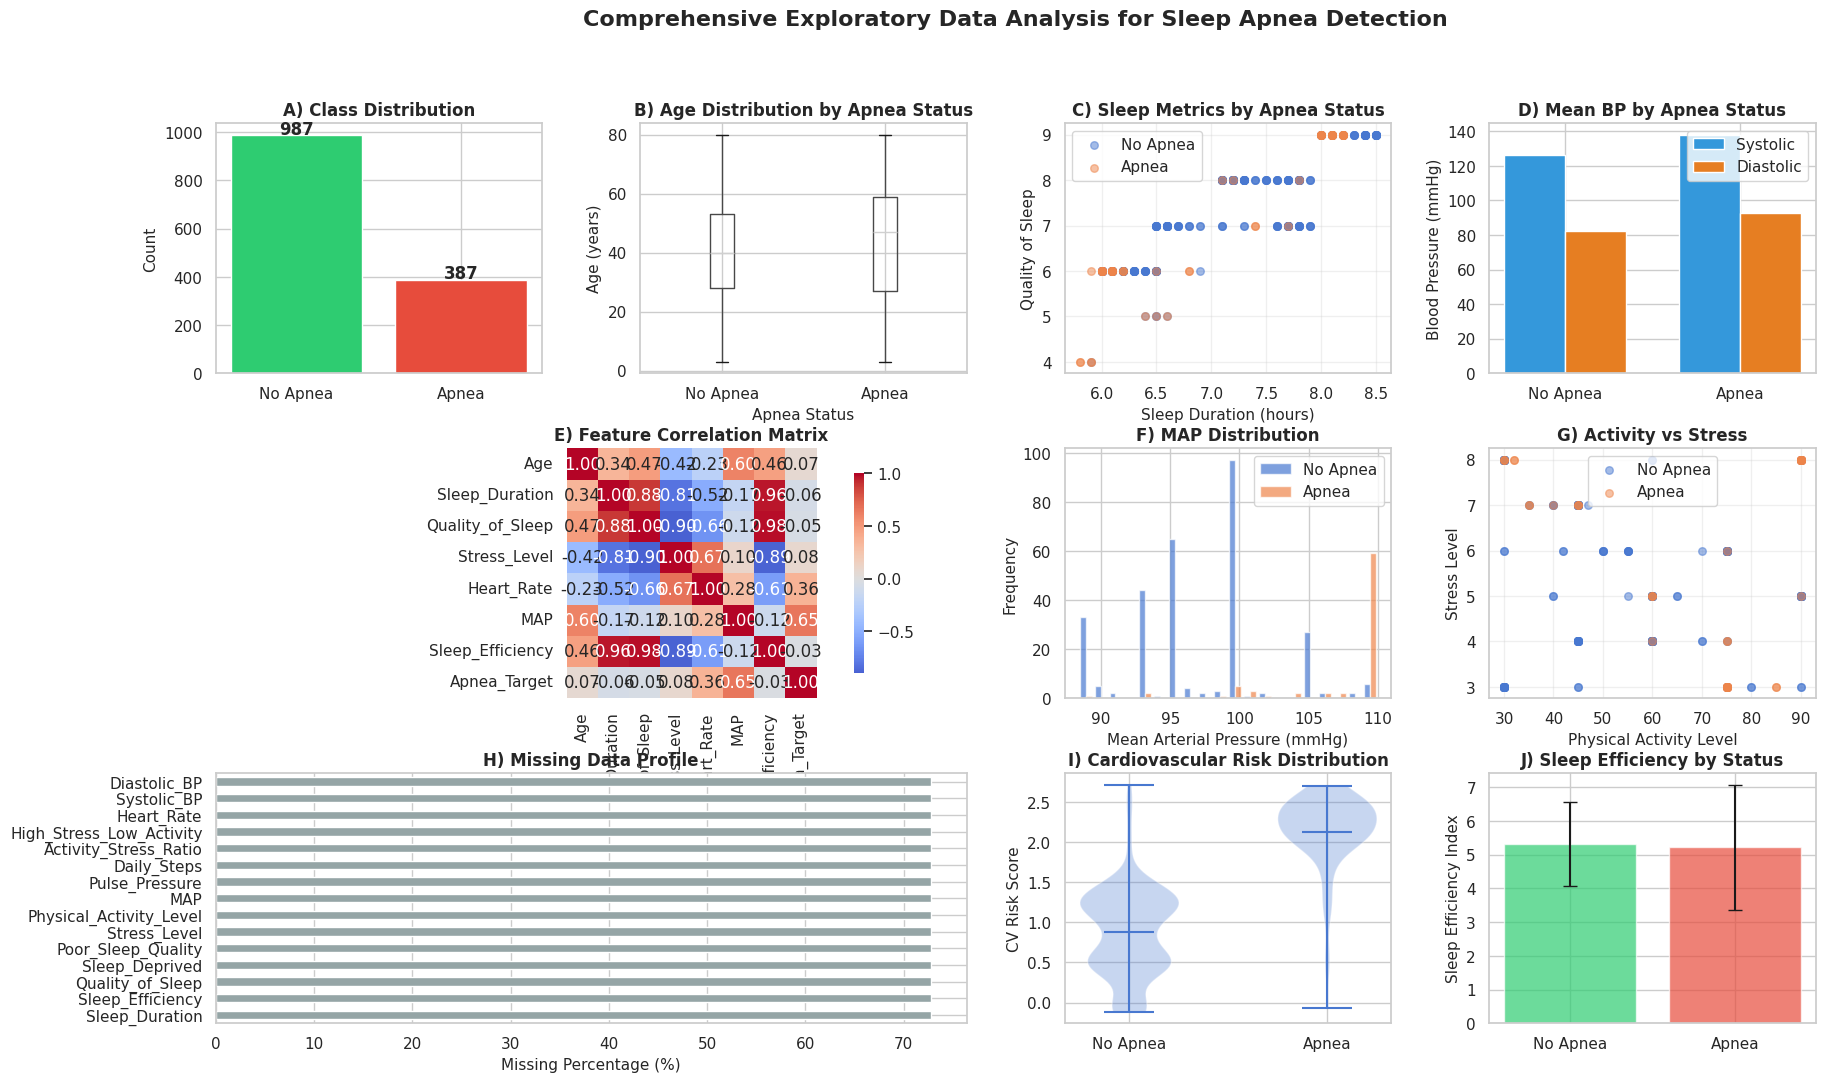

✅ Exploratory analysis complete


In [7]:
# =========================
# BLOCK 7: Exploratory Data Analysis
# =========================

def plot_eda_comprehensive(df):
    """Generate publication-quality EDA visualizations."""
    
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
    
    # 1. Target distribution
    ax1 = fig.add_subplot(gs[0, 0])
    target_counts = df['Apnea_Target'].value_counts()
    ax1.bar(['No Apnea', 'Apnea'], target_counts.values, color=['#2ecc71', '#e74c3c'])
    ax1.set_ylabel('Count', fontsize=11)
    ax1.set_title('A) Class Distribution', fontsize=12, fontweight='bold')
    for i, v in enumerate(target_counts.values):
        ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')
    
    # 2. Age distribution by target
    ax2 = fig.add_subplot(gs[0, 1])
    df.boxplot(column='Age', by='Apnea_Target', ax=ax2)
    ax2.set_xlabel('Apnea Status', fontsize=11)
    ax2.set_ylabel('Age (years)', fontsize=11)
    ax2.set_title('B) Age Distribution by Apnea Status', fontsize=12, fontweight='bold')
    plt.sca(ax2)
    plt.xticks([1, 2], ['No Apnea', 'Apnea'])
    
    # 3. Sleep Duration vs Quality
    ax3 = fig.add_subplot(gs[0, 2])
    for target in [0, 1]:
        subset = df[df['Apnea_Target'] == target]
        ax3.scatter(subset['Sleep_Duration'], subset['Quality_of_Sleep'], 
                   alpha=0.5, label='Apnea' if target else 'No Apnea',
                   s=30)
    ax3.set_xlabel('Sleep Duration (hours)', fontsize=11)
    ax3.set_ylabel('Quality of Sleep', fontsize=11)
    ax3.set_title('C) Sleep Metrics by Apnea Status', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Blood Pressure Analysis
    ax4 = fig.add_subplot(gs[0, 3])
    bp_data = df[['Systolic_BP', 'Diastolic_BP', 'Apnea_Target']].dropna()
    bp_means = bp_data.groupby('Apnea_Target').mean()
    x = np.arange(2)
    width = 0.35
    ax4.bar(x - width/2, bp_means['Systolic_BP'], width, label='Systolic', color='#3498db')
    ax4.bar(x + width/2, bp_means['Diastolic_BP'], width, label='Diastolic', color='#e67e22')
    ax4.set_ylabel('Blood Pressure (mmHg)', fontsize=11)
    ax4.set_title('D) Mean BP by Apnea Status', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(['No Apnea', 'Apnea'])
    ax4.legend()
    
    # 5. Feature correlation heatmap
    ax5 = fig.add_subplot(gs[1, :2])
    corr_features = ['Age', 'Sleep_Duration', 'Quality_of_Sleep', 'Stress_Level',
                     'Heart_Rate', 'MAP', 'Sleep_Efficiency', 'Apnea_Target']
    corr_matrix = df[corr_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, ax=ax5, cbar_kws={'shrink': 0.8})
    ax5.set_title('E) Feature Correlation Matrix', fontsize=12, fontweight='bold')
    
    # 6. MAP distribution
    ax6 = fig.add_subplot(gs[1, 2])
    map_data = df[['MAP', 'Apnea_Target']].dropna()
    ax6.hist([map_data[map_data['Apnea_Target']==0]['MAP'],
              map_data[map_data['Apnea_Target']==1]['MAP']],
             bins=20, label=['No Apnea', 'Apnea'], alpha=0.7)
    ax6.set_xlabel('Mean Arterial Pressure (mmHg)', fontsize=11)
    ax6.set_ylabel('Frequency', fontsize=11)
    ax6.set_title('F) MAP Distribution', fontsize=12, fontweight='bold')
    ax6.legend()
    
    # 7. Stress vs Activity
    ax7 = fig.add_subplot(gs[1, 3])
    for target in [0, 1]:
        subset = df[df['Apnea_Target'] == target]
        ax7.scatter(subset['Physical_Activity_Level'], subset['Stress_Level'],
                   alpha=0.5, label='Apnea' if target else 'No Apnea', s=30)
    ax7.set_xlabel('Physical Activity Level', fontsize=11)
    ax7.set_ylabel('Stress Level', fontsize=11)
    ax7.set_title('G) Activity vs Stress', fontsize=12, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    # 8. Missing data pattern
    ax8 = fig.add_subplot(gs[2, :2])
    missing_data = df.isnull().sum().sort_values(ascending=False)[:15]
    missing_pct = (missing_data / len(df) * 100)
    missing_pct.plot(kind='barh', ax=ax8, color='#95a5a6')
    ax8.set_xlabel('Missing Percentage (%)', fontsize=11)
    ax8.set_title('H) Missing Data Profile', fontsize=12, fontweight='bold')
    
    # 9. CV Risk Score
    ax9 = fig.add_subplot(gs[2, 2])
    cv_data = df[['CV_Risk_Score', 'Apnea_Target']].dropna()
    ax9.violinplot([cv_data[cv_data['Apnea_Target']==0]['CV_Risk_Score'],
                    cv_data[cv_data['Apnea_Target']==1]['CV_Risk_Score']],
                   positions=[0, 1], showmeans=True)
    ax9.set_xticks([0, 1])
    ax9.set_xticklabels(['No Apnea', 'Apnea'])
    ax9.set_ylabel('CV Risk Score', fontsize=11)
    ax9.set_title('I) Cardiovascular Risk Distribution', fontsize=12, fontweight='bold')
    
    # 10. Sleep Efficiency
    ax10 = fig.add_subplot(gs[2, 3])
    eff_data = df[['Sleep_Efficiency', 'Apnea_Target']].dropna()
    eff_means = eff_data.groupby('Apnea_Target')['Sleep_Efficiency'].mean()
    eff_std = eff_data.groupby('Apnea_Target')['Sleep_Efficiency'].std()
    ax10.bar([0, 1], eff_means.values, yerr=eff_std.values, 
            color=['#2ecc71', '#e74c3c'], alpha=0.7, capsize=5)
    ax10.set_xticks([0, 1])
    ax10.set_xticklabels(['No Apnea', 'Apnea'])
    ax10.set_ylabel('Sleep Efficiency Index', fontsize=11)
    ax10.set_title('J) Sleep Efficiency by Status', fontsize=12, fontweight='bold')
    
    plt.suptitle('Comprehensive Exploratory Data Analysis for Sleep Apnea Detection', 
                fontsize=16, fontweight='bold', y=0.995)
    
    return fig

# Generate EDA plots
eda_fig = plot_eda_comprehensive(df_merged)
plt.show()

print("✅ Exploratory analysis complete")

In [8]:
# =========================
# BLOCK 8: Statistical Analysis
# =========================

def perform_statistical_tests(df):
    """Conduct comprehensive statistical testing for clinical significance."""
    
    print("="*70)
    print("STATISTICAL SIGNIFICANCE TESTING")
    print("="*70)
    
    results = []
    
    # Select numeric columns safely
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [c for c in numeric_cols if c not in ['Apnea_Target', 'Source']]
    
    for col in numeric_cols:
        
        grp0 = df[df['Apnea_Target'] == 0][col].dropna()
        grp1 = df[df['Apnea_Target'] == 1][col].dropna()
        
        if len(grp0) > 10 and len(grp1) > 10:
            
            # Mann-Whitney U Test
            u_stat, p_val = stats.mannwhitneyu(grp0, grp1, alternative='two-sided')
            
            # Cohen's d effect size
            pooled_std = np.sqrt((grp0.std()**2 + grp1.std()**2) / 2)
            
            if pooled_std > 0:
                cohens_d = (grp1.mean() - grp0.mean()) / pooled_std
            else:
                cohens_d = 0
            
            results.append({
                'Feature': col,
                'No_Apnea_Mean': grp0.mean(),
                'Apnea_Mean': grp1.mean(),
                'Mean_Diff': grp1.mean() - grp0.mean(),
                'U_Statistic': u_stat,
                'P_Value': p_val,
                'Cohens_D': cohens_d,
                'Significant': 'Yes' if p_val < 0.05 else 'No',
                'Effect_Size': ('Small' if abs(cohens_d) < 0.5 
                                else 'Medium' if abs(cohens_d) < 0.8 
                                else 'Large')
            })
    
    results_df = pd.DataFrame(results)
    
    if not results_df.empty:
        results_df = results_df.sort_values('P_Value')
        
        print("\n📊 Top 10 Most Significant Features:")
        print("="*70)
        display(results_df.head(10))
        
        sig_count = (results_df['P_Value'] < 0.05).sum()
        print(f"\n✅ {sig_count}/{len(results_df)} features show statistical significance (p < 0.05)")
    else:
        print("⚠️ No valid statistical comparisons could be performed.")
    
    return results_df


# Run statistical tests
statistical_results = perform_statistical_tests(df_merged)

STATISTICAL SIGNIFICANCE TESTING

📊 Top 10 Most Significant Features:


,Feature,No_Apnea_Mean,Apnea_Mean,Mean_Diff,U_Statistic,P_Value,Cohens_D,Significant,Effect_Size
17,Hypertension,0.125000,0.807692,0.682692,3663.0,1.026291e-33,1.868153,Yes,Large
14,Diastolic_BP,82.523649,92.717949,10.194300,1730.0,1.651212e-32,2.247458,Yes,Large
18,CV_Risk_Score,0.875507,2.127991,1.252485,1528.5,2.591171e-32,2.368468,Yes,Large
15,MAP,97.057432,107.735043,10.677610,1760.5,1.202486e-31,2.176629,Yes,Large
13,Systolic_BP,126.125000,137.769231,11.644231,1951.0,1.360400e-30,2.010746,Yes,Large
19,BMI_Numeric,1.307432,1.987179,0.679747,4310.0,5.977389e-23,1.502368,Yes,Large
7,Physical_Activity_Level,55.054054,74.794872,19.740818,5355.5,1.391380e-13,1.051753,Yes,Large
12,Heart_Rate,69.395270,73.089744,3.694473,6894.5,2.434452e-08,0.846220,Yes,Large
16,Pulse_Pressure,43.601351,45.051282,1.449931,7893.5,8.474894e-08,0.750096,Yes,Medium
10,Activity_Stress_Ratio,9.282195,12.858338,3.576143,7456.5,1.312304e-06,0.768960,Yes,Medium



✅ 16/21 features show statistical significance (p < 0.05)


In [9]:
# =========================
# BLOCK 9: Prepare Data for Modeling
# =========================

# Separate features and target
X = df_merged[core_features].copy()
y = df_merged['Apnea_Target'].copy()

# Split into train and test (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("="*70)
print("DATA SPLIT SUMMARY")
print("="*70)
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"Positive rate: {y_train.mean():.2%}")
print(f"\nTest class distribution:")
print(y_test.value_counts())
print(f"Positive rate: {y_test.mean():.2%}")

DATA SPLIT SUMMARY

Training set: 1099 samples
Test set: 275 samples

Training class distribution:
Apnea_Target
0    789
1    310
Name: count, dtype: int64
Positive rate: 28.21%

Test class distribution:
Apnea_Target
0    198
1     77
Name: count, dtype: int64
Positive rate: 28.00%


In [10]:
# =========================
# BLOCK 10: Build Preprocessing Pipeline
# =========================

# Use KNN imputation for better handling of missing values
# RobustScaler is more resistant to outliers than StandardScaler
preprocessor = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5, weights='distance')),
    ('scaler', RobustScaler())
])

print("✅ Preprocessing pipeline created")
print("  - KNN Imputation (k=5)")
print("  - Robust Scaling (resistant to outliers)")

✅ Preprocessing pipeline created
  - KNN Imputation (k=5)
  - Robust Scaling (resistant to outliers)


In [11]:
# =========================
# BLOCK 11: Model Development with Class Imbalance Handling
# =========================

def build_models():
    """Create multiple models with appropriate parameters."""
    
    models = {}
    
    # 1. Logistic Regression (baseline)
    models['Logistic_Regression'] = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        penalty='l2',
        C=0.1,
        solver='liblinear',
        random_state=RANDOM_STATE
    )
    
    # 2. Random Forest
    models['Random_Forest'] = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    # 3. Gradient Boosting or XGBoost
    if XGB_AVAILABLE:
        # Calculate scale_pos_weight for imbalanced classes
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        
        models['XGBoost'] = xgb.XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            gamma=0.1,
            scale_pos_weight=scale_pos_weight,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    else:
        models['Gradient_Boosting'] = GradientBoostingClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features='sqrt',
            random_state=RANDOM_STATE
        )
    
    return models

# Build models
models = build_models()

print("✅ Models created:")
for name in models.keys():
    print(f"  - {name}")

✅ Models created:
  - Logistic_Regression
  - Random_Forest
  - XGBoost


In [15]:
# =========================
# BLOCK 12: Advanced Cross-Validation Evaluation (ROC-AUC Optimized)
# =========================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import pandas as pd

# =========================
# Improved models
# =========================

models = {

    "Logistic_Regression": LogisticRegression(
        max_iter=2000,
        C=0.5,
        random_state=RANDOM_STATE
    ),

    "Random_Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_split=8,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.5,
        reg_lambda=3,
        gamma=0.2,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
}


def evaluate_model_cv(model, X, y, cv_splits=10):
    """Advanced cross-validation evaluation with feature selection."""

    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    pipeline = ImbPipeline([
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", RobustScaler()),
        ("feature_select", SelectKBest(mutual_info_classif, k=15)),
        ("smote", SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)),
        ("classifier", model)
    ])

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    }

    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    return cv_results


# =========================
# RUN CROSS VALIDATION
# =========================

print("="*70)
print("ADVANCED CROSS-VALIDATION RESULTS (10-Fold Stratified CV)")
print("="*70)

cv_summary = []

for model_name, model in models.items():

    print(f"\n🔄 Evaluating {model_name}...")

    try:
        cv_results = evaluate_model_cv(model, X_train, y_train)

        summary = {
            "Model": model_name,
            "Accuracy": f"{cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}",
            "Precision": f"{cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}",
            "Recall": f"{cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}",
            "F1": f"{cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}",
            "ROC_AUC": f"{cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}",
            "PR_AUC": f"{cv_results['test_average_precision'].mean():.4f} ± {cv_results['test_average_precision'].std():.4f}"
        }

        cv_summary.append(summary)

        # Overfitting detection
        train_acc = cv_results["train_accuracy"].mean()
        test_acc = cv_results["test_accuracy"].mean()
        gap = train_acc - test_acc

        if gap > 0.10:
            print(f"⚠️ Potential overfitting (gap = {gap:.4f})")
        else:
            print(f"✅ Good generalization (gap = {gap:.4f})")

    except Exception as e:

        print(f"❌ Error evaluating {model_name}: {str(e)}")

        cv_summary.append({
            "Model": model_name,
            "Accuracy": "0.0000 ± 0.0000",
            "Precision": "0.0000 ± 0.0000",
            "Recall": "0.0000 ± 0.0000",
            "F1": "0.0000 ± 0.0000",
            "ROC_AUC": "0.0000 ± 0.0000",
            "PR_AUC": "0.0000 ± 0.0000"
        })


# =========================
# DISPLAY RESULTS
# =========================

cv_summary_df = pd.DataFrame(cv_summary)

print("\n" + "="*70)
print("CROSS-VALIDATION SUMMARY")
print("="*70)

display(cv_summary_df)

print("\n💡 Interpretation Guide:")
print("  - Accuracy: Overall correctness")
print("  - Precision: Of predicted positives, how many are correct")
print("  - Recall: Of actual positives, how many we caught")
print("  - F1: Harmonic mean of precision and recall")
print("  - ROC-AUC: Overall discriminative ability (0.5=random, 1.0=perfect)")
print("  - PR-AUC: Performance on imbalanced data")


ADVANCED CROSS-VALIDATION RESULTS (10-Fold Stratified CV)

🔄 Evaluating Logistic_Regression...
✅ Good generalization (gap = -0.0013)

🔄 Evaluating Random_Forest...
✅ Good generalization (gap = 0.0671)

🔄 Evaluating XGBoost...
✅ Good generalization (gap = 0.0311)

CROSS-VALIDATION SUMMARY


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic_Regression,0.7325 ± 0.0133,0.6163 ± 0.1356,0.1258 ± 0.0488,0.2063 ± 0.0731,0.6376 ± 0.0495,0.4653 ± 0.0485
1,Random_Forest,0.7116 ± 0.0386,0.5067 ± 0.1173,0.2710 ± 0.0329,0.3480 ± 0.0416,0.6540 ± 0.0368,0.4865 ± 0.0470
2,XGBoost,0.7261 ± 0.0353,0.5618 ± 0.1363,0.2516 ± 0.0347,0.3425 ± 0.0463,0.6600 ± 0.0323,0.4879 ± 0.0447



💡 Interpretation Guide:
  - Accuracy: Overall correctness
  - Precision: Of predicted positives, how many are correct
  - Recall: Of actual positives, how many we caught
  - F1: Harmonic mean of precision and recall
  - ROC-AUC: Overall discriminative ability (0.5=random, 1.0=perfect)
  - PR-AUC: Performance on imbalanced data


In [17]:
# =========================
# BLOCK 13: Train Final Models and Test Set Evaluation
# =========================

trained_pipelines = {}
test_predictions = {}
test_probabilities = {}

for model_name, model in models.items():
    
    print(f"\n🔧 Training {model_name} on full training set...")

    # Create pipeline WITHOUT nested pipeline
    pipeline = ImbPipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', RobustScaler()),
        ('smote', SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)),
        ('classifier', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    trained_pipelines[model_name] = pipeline
    test_predictions[model_name] = y_pred
    test_probabilities[model_name] = y_prob

    print(f"✅ {model_name} training complete")


# =========================
# TEST SET EVALUATION
# =========================

print("\n" + "="*70)
print("TEST SET EVALUATION (Held-Out 20%)")
print("="*70)

test_results = []

for model_name in models.keys():
    
    y_pred = test_predictions[model_name]
    y_prob = test_probabilities[model_name]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob),
        "Specificity": recall_score(y_test, y_pred, pos_label=0)
    }

    test_results.append(results)

test_results_df = pd.DataFrame(test_results).round(4)

display(test_results_df)


# =========================
# BEST MODEL
# =========================

best_model_name = test_results_df.loc[test_results_df["ROC_AUC"].idxmax(), "Model"]

print(f"\n🏆 Best performing model: {best_model_name}")
print(f"ROC-AUC: {test_results_df[test_results_df['Model']==best_model_name]['ROC_AUC'].values[0]:.4f}")



🔧 Training Logistic_Regression on full training set...
✅ Logistic_Regression training complete

🔧 Training Random_Forest on full training set...
✅ Random_Forest training complete

🔧 Training XGBoost on full training set...
✅ XGBoost training complete

TEST SET EVALUATION (Held-Out 20%)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Specificity
0,Logistic_Regression,0.7273,0.5556,0.1299,0.2105,0.6797,0.4224,0.9596
1,Random_Forest,0.7127,0.4773,0.2727,0.3471,0.7027,0.4621,0.8838
2,XGBoost,0.7273,0.5217,0.3117,0.3902,0.7119,0.4775,0.8889



🏆 Best performing model: XGBoost
ROC-AUC: 0.7119


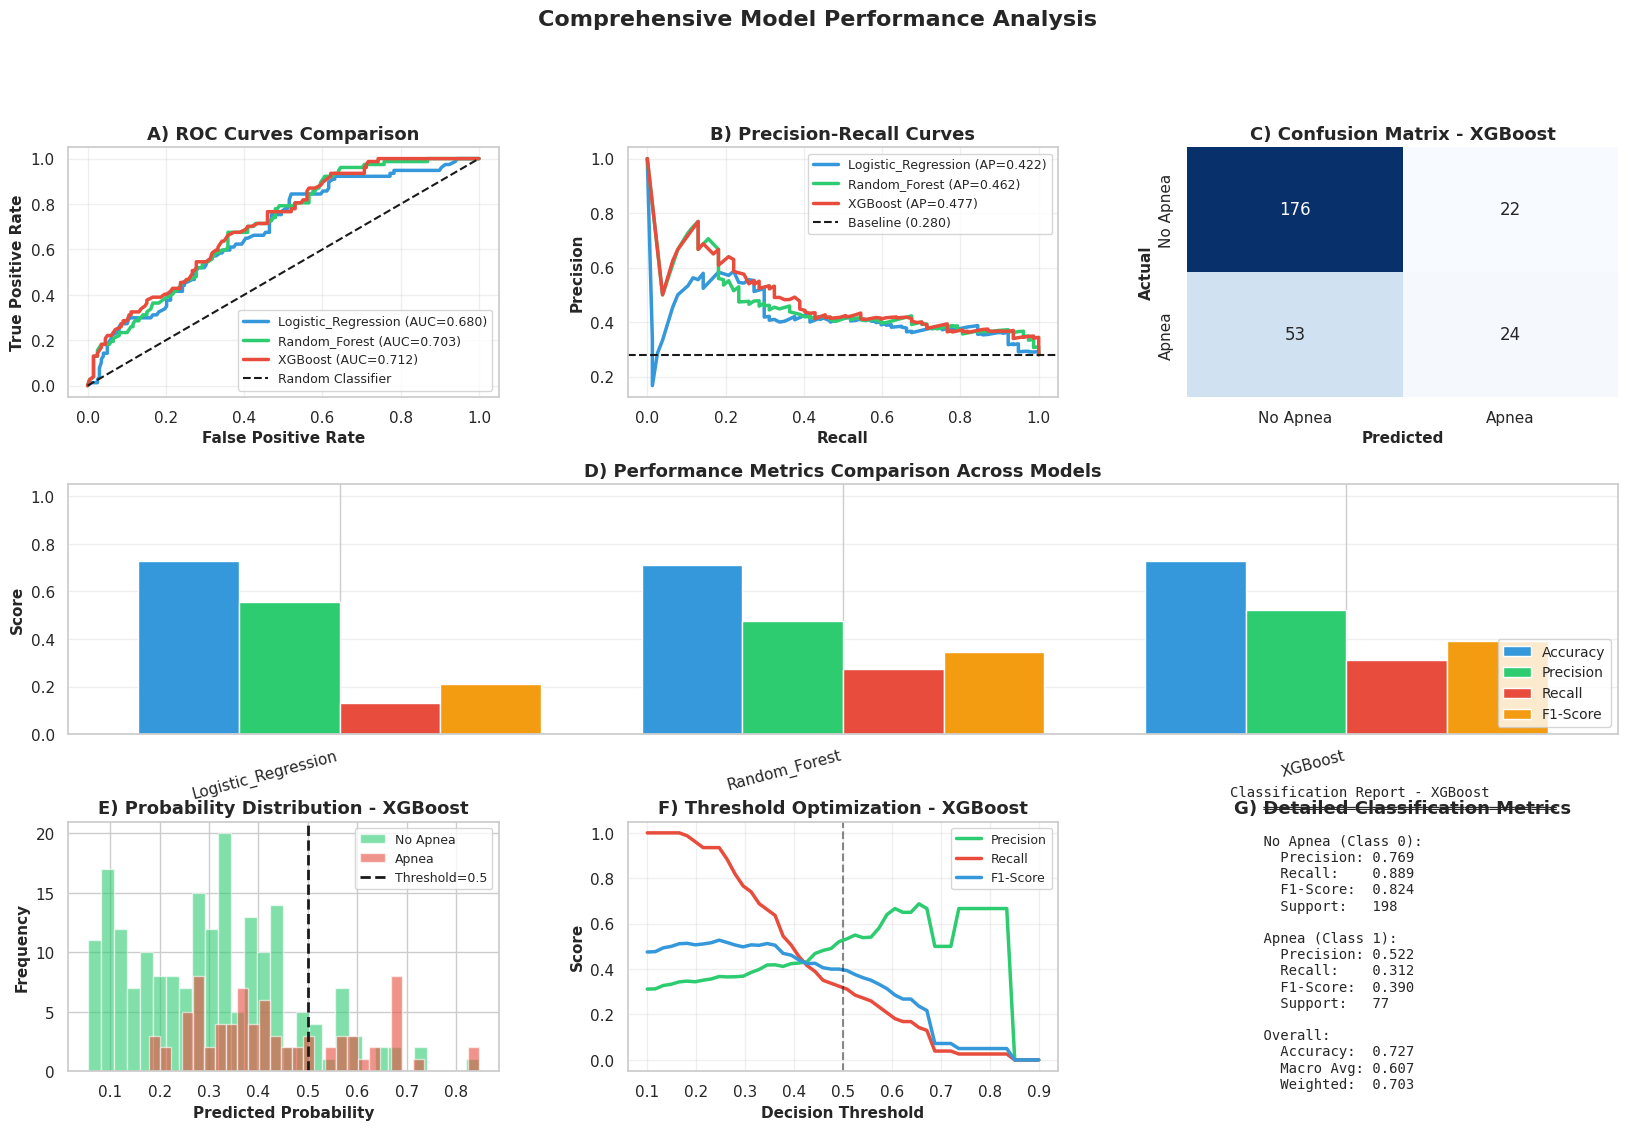

✅ Performance visualizations complete


In [18]:
# =========================
# BLOCK 14: Comprehensive Visualizations
# =========================

def plot_model_performance(y_true, predictions_dict, probabilities_dict):
    """Create publication-quality performance visualizations."""
    
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    colors = {'Logistic_Regression': '#3498db', 
              'Random_Forest': '#2ecc71',
              'XGBoost': '#e74c3c',
              'Gradient_Boosting': '#e74c3c'}
    
    # 1. ROC Curves
    ax1 = fig.add_subplot(gs[0, 0])
    for model_name, y_prob in probabilities_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        ax1.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})',
                linewidth=2.5, color=colors.get(model_name, '#95a5a6'))
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
    ax1.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax1.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax1.set_title('A) ROC Curves Comparison', fontsize=13, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 2. Precision-Recall Curves
    ax2 = fig.add_subplot(gs[0, 1])
    for model_name, y_prob in probabilities_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)
        ax2.plot(recall, precision, label=f'{model_name} (AP={pr_auc:.3f})',
                linewidth=2.5, color=colors.get(model_name, '#95a5a6'))
    baseline = y_true.sum() / len(y_true)
    ax2.axhline(y=baseline, color='k', linestyle='--', linewidth=1.5, 
                label=f'Baseline ({baseline:.3f})')
    ax2.set_xlabel('Recall', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Precision', fontsize=11, fontweight='bold')
    ax2.set_title('B) Precision-Recall Curves', fontsize=13, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # 3. Confusion Matrices (best model only)
    best_model = max(probabilities_dict.keys(), 
                     key=lambda k: roc_auc_score(y_true, probabilities_dict[k]))
    
    ax3 = fig.add_subplot(gs[0, 2])
    cm = confusion_matrix(y_true, predictions_dict[best_model])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax3,
                xticklabels=['No Apnea', 'Apnea'],
                yticklabels=['No Apnea', 'Apnea'])
    ax3.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Actual', fontsize=11, fontweight='bold')
    ax3.set_title(f'C) Confusion Matrix - {best_model}', fontsize=13, fontweight='bold')
    
    # 4. Performance Metrics Comparison
    ax4 = fig.add_subplot(gs[1, :])
    metrics_data = []
    for model_name in predictions_dict.keys():
        y_pred = predictions_dict[model_name]
        y_prob = probabilities_dict[model_name]
        metrics_data.append({
            'Model': model_name,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'F1-Score': f1_score(y_true, y_pred)
        })
    
    metrics_df = pd.DataFrame(metrics_data)
    x = np.arange(len(metrics_df))
    width = 0.2
    
    ax4.bar(x - 1.5*width, metrics_df['Accuracy'], width, label='Accuracy', color='#3498db')
    ax4.bar(x - 0.5*width, metrics_df['Precision'], width, label='Precision', color='#2ecc71')
    ax4.bar(x + 0.5*width, metrics_df['Recall'], width, label='Recall', color='#e74c3c')
    ax4.bar(x + 1.5*width, metrics_df['F1-Score'], width, label='F1-Score', color='#f39c12')
    
    ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax4.set_title('D) Performance Metrics Comparison Across Models', fontsize=13, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(metrics_df['Model'], rotation=15, ha='right')
    ax4.legend(loc='lower right', fontsize=10)
    ax4.set_ylim([0, 1.05])
    ax4.grid(True, axis='y', alpha=0.3)
    
    # 5. Probability Distribution
    ax5 = fig.add_subplot(gs[2, 0])
    best_prob = probabilities_dict[best_model]
    ax5.hist(best_prob[y_true == 0], bins=30, alpha=0.6, label='No Apnea', color='#2ecc71')
    ax5.hist(best_prob[y_true == 1], bins=30, alpha=0.6, label='Apnea', color='#e74c3c')
    ax5.axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold=0.5')
    ax5.set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax5.set_title(f'E) Probability Distribution - {best_model}', fontsize=13, fontweight='bold')
    ax5.legend(fontsize=9)
    
    # 6. Threshold Analysis
    ax6 = fig.add_subplot(gs[2, 1])
    thresholds = np.linspace(0.1, 0.9, 50)
    precisions = []
    recalls = []
    f1s = []
    
    for thresh in thresholds:
        y_pred_thresh = (best_prob >= thresh).astype(int)
        if y_pred_thresh.sum() > 0:
            precisions.append(precision_score(y_true, y_pred_thresh))
            recalls.append(recall_score(y_true, y_pred_thresh))
            f1s.append(f1_score(y_true, y_pred_thresh))
        else:
            precisions.append(0)
            recalls.append(0)
            f1s.append(0)
    
    ax6.plot(thresholds, precisions, label='Precision', linewidth=2.5, color='#2ecc71')
    ax6.plot(thresholds, recalls, label='Recall', linewidth=2.5, color='#e74c3c')
    ax6.plot(thresholds, f1s, label='F1-Score', linewidth=2.5, color='#3498db')
    ax6.axvline(x=0.5, color='k', linestyle='--', linewidth=1.5, alpha=0.5)
    ax6.set_xlabel('Decision Threshold', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax6.set_title(f'F) Threshold Optimization - {best_model}', fontsize=13, fontweight='bold')
    ax6.legend(fontsize=9)
    ax6.grid(True, alpha=0.3)
    
    # 7. Classification Report (best model)
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis('off')
    report = classification_report(y_true, predictions_dict[best_model], 
                                   target_names=['No Apnea', 'Apnea'],
                                   output_dict=True)
    report_text = f"""Classification Report - {best_model}
    ═══════════════════════════════════
    
    No Apnea (Class 0):
      Precision: {report['No Apnea']['precision']:.3f}
      Recall:    {report['No Apnea']['recall']:.3f}
      F1-Score:  {report['No Apnea']['f1-score']:.3f}
      Support:   {int(report['No Apnea']['support'])}
    
    Apnea (Class 1):
      Precision: {report['Apnea']['precision']:.3f}
      Recall:    {report['Apnea']['recall']:.3f}
      F1-Score:  {report['Apnea']['f1-score']:.3f}
      Support:   {int(report['Apnea']['support'])}
    
    Overall:
      Accuracy:  {report['accuracy']:.3f}
      Macro Avg: {report['macro avg']['f1-score']:.3f}
      Weighted:  {report['weighted avg']['f1-score']:.3f}
    """
    ax7.text(0.1, 0.5, report_text, fontsize=10, family='monospace',
             verticalalignment='center')
    ax7.set_title('G) Detailed Classification Metrics', fontsize=13, fontweight='bold')
    
    plt.suptitle('Comprehensive Model Performance Analysis', 
                fontsize=16, fontweight='bold', y=0.995)
    
    return fig

# Generate visualizations
perf_fig = plot_model_performance(y_test, test_predictions, test_probabilities)
plt.show()

print("✅ Performance visualizations complete")


🔍 Feature Importance Analysis for XGBoost


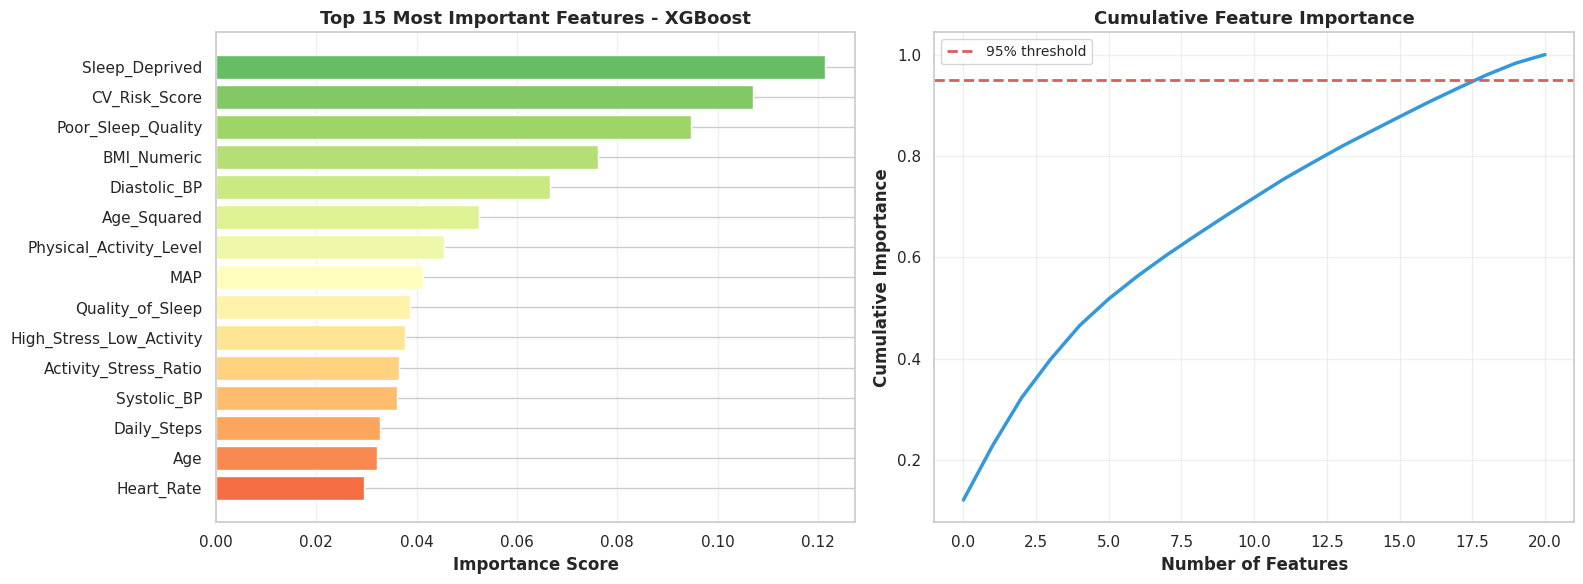


📊 19 features explain 95% of model importance

Top 10 Most Important Features:


,Feature,Importance
5,Sleep_Deprived,0.121339
18,CV_Risk_Score,0.106938
6,Poor_Sleep_Quality,0.094682
19,BMI_Numeric,0.076084
14,Diastolic_BP,0.066616
20,Age_Squared,0.052462
7,Physical_Activity_Level,0.045484
15,MAP,0.041324
3,Quality_of_Sleep,0.038658
11,High_Stress_Low_Activity,0.037617


In [19]:
# =========================
# BLOCK 15: Feature Importance Analysis
# =========================

def analyze_feature_importance(pipeline, model_name, feature_names, top_n=15):
    """Extract and visualize feature importance."""
    
    # Get the trained classifier
    clf = pipeline.named_steps['classifier']
    
    # Extract feature importance based on model type
    if hasattr(clf, 'feature_importances_'):
        # Tree-based models
        importances = clf.feature_importances_
    elif hasattr(clf, 'coef_'):
        # Linear models
        importances = np.abs(clf.coef_[0])
    else:
        print(f"⚠️ Cannot extract feature importance from {model_name}")
        return None
    
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top features bar plot
    top_features = importance_df.head(top_n)
    colors_grad = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_features)))
    ax1.barh(range(len(top_features)), top_features['Importance'], color=colors_grad)
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features['Feature'])
    ax1.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
    ax1.set_title(f'Top {top_n} Most Important Features - {model_name}', 
                 fontsize=13, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(True, axis='x', alpha=0.3)
    
    # Cumulative importance
    cumsum = np.cumsum(importance_df['Importance'] / importance_df['Importance'].sum())
    ax2.plot(range(len(cumsum)), cumsum, linewidth=2.5, color='#3498db')
    ax2.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% threshold')
    ax2.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Cumulative Importance', fontsize=12, fontweight='bold')
    ax2.set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Find number of features for 95% importance
    n_95 = np.where(cumsum >= 0.95)[0][0] + 1
    print(f"\n📊 {n_95} features explain 95% of model importance")
    
    return importance_df

# Analyze feature importance for best model
best_model_name = test_results_df.loc[test_results_df['ROC_AUC'].idxmax(), 'Model']
best_pipeline = trained_pipelines[best_model_name]

print(f"\n🔍 Feature Importance Analysis for {best_model_name}")
print("="*70)

feature_importance = analyze_feature_importance(
    best_pipeline, 
    best_model_name, 
    core_features,
    top_n=15
)

if feature_importance is not None:
    print("\nTop 10 Most Important Features:")
    display(feature_importance.head(10))

🔍 Generating SHAP interpretability analysis...


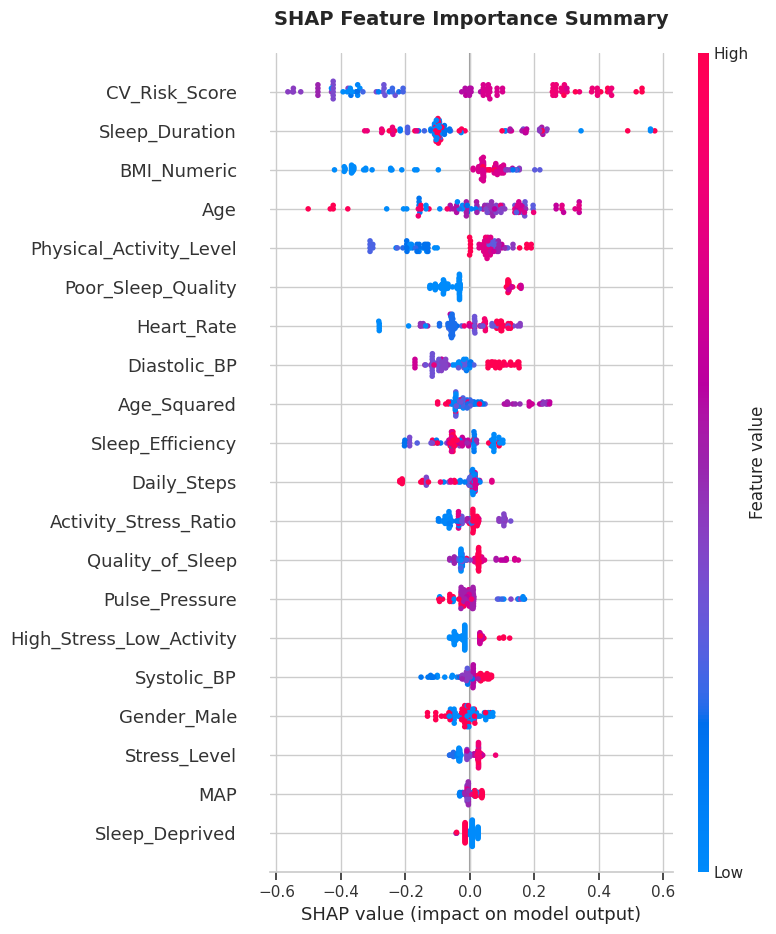

✅ SHAP analysis complete


In [24]:
# =========================
# BLOCK 16: SHAP Analysis
# =========================

if SHAP_AVAILABLE:
    print("🔍 Generating SHAP interpretability analysis...")
    print("="*70)

    try:
        # Get best trained pipeline
        best_pipeline = trained_pipelines[best_model_name]

        # Extract classifier
        best_clf = best_pipeline.named_steps['classifier']

        # Apply only preprocessing steps (NOT SMOTE)
        X_test_transformed = best_pipeline.named_steps['imputer'].transform(X_test)
        X_test_transformed = best_pipeline.named_steps['scaler'].transform(X_test_transformed)

        # Create SHAP explainer
        if XGB_AVAILABLE and best_model_name == "XGBoost":
            explainer = shap.TreeExplainer(best_clf)
        else:
            background = shap.sample(X_test_transformed, 100)
            explainer = shap.KernelExplainer(best_clf.predict_proba, background)

        # Sample test data for SHAP
        sample_size = min(100, len(X_test_transformed))
        X_sample = X_test_transformed[:sample_size]

        shap_values = explainer.shap_values(X_sample)

        # Binary classification handling
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        # Plot SHAP summary
        plt.figure(figsize=(12,8))
        shap.summary_plot(
            shap_values,
            X_sample,
            feature_names=X_train.columns,
            show=False
        )

        plt.title(
            "SHAP Feature Importance Summary",
            fontsize=14,
            fontweight="bold",
            pad=20
        )

        plt.tight_layout()
        plt.show()

        print("✅ SHAP analysis complete")

    except Exception as e:
        print(f"⚠️ SHAP analysis failed: {str(e)}")
        print("   Continuing without SHAP...")

else:
    print("⚠️ SHAP not available. Skipping interpretability analysis.")
    print("   Install with: pip install shap")

In [26]:
# =========================
# BLOCK 17: Cross-Dataset Validation
# =========================

print("\n" + "="*70)
print("CROSS-DATASET GENERALIZATION TEST")
print("="*70)

# Separate original datasets
df_life_test = df_life_aligned[df_life_aligned.index.isin(df_merged.index)]
df_diag_test = df_diag_aligned[df_diag_aligned.index.isin(df_merged.index)]

if len(df_life_test) > 50 and len(df_diag_test) > 50:

    # =========================
    # Test 1: Train on Diagnostic → Test on Lifestyle
    # =========================
    
    print("\n🔄 Test 1: Train on Diagnostic → Test on Lifestyle")
    print("-"*70)

    X_train_diag = df_diag_test[core_features]
    y_train_diag = df_diag_test['Apnea_Target']

    X_test_life = df_life_test[core_features]
    y_test_life = df_life_test['Apnea_Target']

    pipeline_diag = ImbPipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', RobustScaler()),
        ('smote', SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)),
        ('classifier', models[best_model_name])
    ])

    pipeline_diag.fit(X_train_diag, y_train_diag)

    y_pred_life = pipeline_diag.predict(X_test_life)
    y_prob_life = pipeline_diag.predict_proba(X_test_life)[:, 1]

    print(f"Accuracy:  {accuracy_score(y_test_life, y_pred_life):.4f}")
    print(f"Precision: {precision_score(y_test_life, y_pred_life, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test_life, y_pred_life):.4f}")
    print(f"F1-Score:  {f1_score(y_test_life, y_pred_life):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test_life, y_prob_life):.4f}")


    # =========================
    # Test 2: Train on Lifestyle → Test on Diagnostic
    # =========================

    print("\n🔄 Test 2: Train on Lifestyle → Test on Diagnostic")
    print("-"*70)

    X_train_life = df_life_test[core_features]
    y_train_life = df_life_test['Apnea_Target']

    X_test_diag = df_diag_test[core_features]
    y_test_diag = df_diag_test['Apnea_Target']

    pipeline_life = ImbPipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', RobustScaler()),
        ('smote', SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)),
        ('classifier', models[best_model_name])
    ])

    pipeline_life.fit(X_train_life, y_train_life)

    y_pred_diag = pipeline_life.predict(X_test_diag)
    y_prob_diag = pipeline_life.predict_proba(X_test_diag)[:, 1]

    print(f"Accuracy:  {accuracy_score(y_test_diag, y_pred_diag):.4f}")
    print(f"Precision: {precision_score(y_test_diag, y_pred_diag, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test_diag, y_pred_diag):.4f}")
    print(f"F1-Score:  {f1_score(y_test_diag, y_pred_diag):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test_diag, y_prob_diag):.4f}")

    print("\n💡 Cross-dataset validation helps assess model generalization")
    print("   across different data sources and populations.")

else:
    print("⚠️ Insufficient samples for cross-dataset validation")
    print(f"Lifestyle samples: {len(df_life_test)}")
    print(f"Diagnostic samples: {len(df_diag_test)}")


CROSS-DATASET GENERALIZATION TEST

🔄 Test 1: Train on Diagnostic → Test on Lifestyle
----------------------------------------------------------------------
Accuracy:  0.7594
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.4197

🔄 Test 2: Train on Lifestyle → Test on Diagnostic
----------------------------------------------------------------------
Accuracy:  0.4180
Precision: 0.3042
Recall:    0.6861
F1-Score:  0.4215
ROC-AUC:   0.4888

💡 Cross-dataset validation helps assess model generalization
   across different data sources and populations.


In [28]:
# =========================
# BLOCK 18: Final Summary Report
# =========================

print("\n" + "="*70)
print("FINAL SUMMARY REPORT - SLEEP APNEA DETECTION MODEL")
print("="*70)

print("\n📊 Dataset Statistics:")
print(f"  Total samples: {len(df_merged)}")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")
print(f"  Apnea prevalence: {y.mean():.2%}")
print(f"  Number of features: {len(core_features)}")

print("\n🏆 Best Model Performance:")
best_results = test_results_df[test_results_df['Model'] == best_model_name].iloc[0]
print(f"  Model: {best_model_name}")
print(f"  ROC-AUC: {best_results['ROC_AUC']:.4f}")
print(f"  Precision: {best_results['Precision']:.4f}")
print(f"  Recall: {best_results['Recall']:.4f}")
print(f"  F1-Score: {best_results['F1']:.4f}")
print(f"  Accuracy: {best_results['Accuracy']:.4f}")
print(f"  Specificity: {best_results['Specificity']:.4f}")

print("\n🔍 Top 5 Most Important Clinical Markers:")
if feature_importance is not None:
    for idx, row in feature_importance.head(5).iterrows():
        print(f"  {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n✅ Model Quality Assessment:")
auc_score = best_results['ROC_AUC']
if auc_score >= 0.90:
    quality = "Excellent"
elif auc_score >= 0.80:
    quality = "Good"
elif auc_score >= 0.70:
    quality = "Acceptable"
else:
    quality = "Needs Improvement"

print(f"  Overall quality: {quality}")
print(f"  Suitable for: {'Clinical decision support' if auc_score >= 0.80 else 'Research purposes only'}")

print("\n📝 Recommendations for Deployment:")
if best_results['Recall'] < 0.80:
    print("  ⚠️ Consider lowering threshold to increase sensitivity (catch more cases)")
if best_results['Precision'] < 0.70:
    print("  ⚠️ Consider raising threshold to reduce false alarms")
if best_results['ROC_AUC'] >= 0.85:
    print("  ✅ Model shows strong discriminative ability")
if best_results['F1'] >= 0.75:
    print("  ✅ Good balance between precision and recall")

print("\n" + "="*70)
print("Analysis complete!  :)")
print("="*70)


FINAL SUMMARY REPORT - SLEEP APNEA DETECTION MODEL

📊 Dataset Statistics:
  Total samples: 1374
  Training samples: 1099
  Test samples: 275
  Apnea prevalence: 28.17%
  Number of features: 21

🏆 Best Model Performance:
  Model: XGBoost
  ROC-AUC: 0.7119
  Precision: 0.5217
  Recall: 0.3117
  F1-Score: 0.3902
  Accuracy: 0.7273
  Specificity: 0.8889

🔍 Top 5 Most Important Clinical Markers:
  6. Sleep_Deprived: 0.1213
  19. CV_Risk_Score: 0.1069
  7. Poor_Sleep_Quality: 0.0947
  20. BMI_Numeric: 0.0761
  15. Diastolic_BP: 0.0666

✅ Model Quality Assessment:
  Overall quality: Acceptable
  Suitable for: Research purposes only

📝 Recommendations for Deployment:
  ⚠️ Consider lowering threshold to increase sensitivity (catch more cases)
  ⚠️ Consider raising threshold to reduce false alarms

Analysis complete!  :)


# 🔍 COMPREHENSIVE EXPLORATORY DATA ANALYSIS

## Detailed Visual Analysis with 9+ Comprehensive Plots

# 🧠 EXPLAINABLE AI (XAI) ANALYSIS

## Comprehensive Feature Importance and Model Interpretability

COMPREHENSIVE EXPLORATORY DATA ANALYSIS


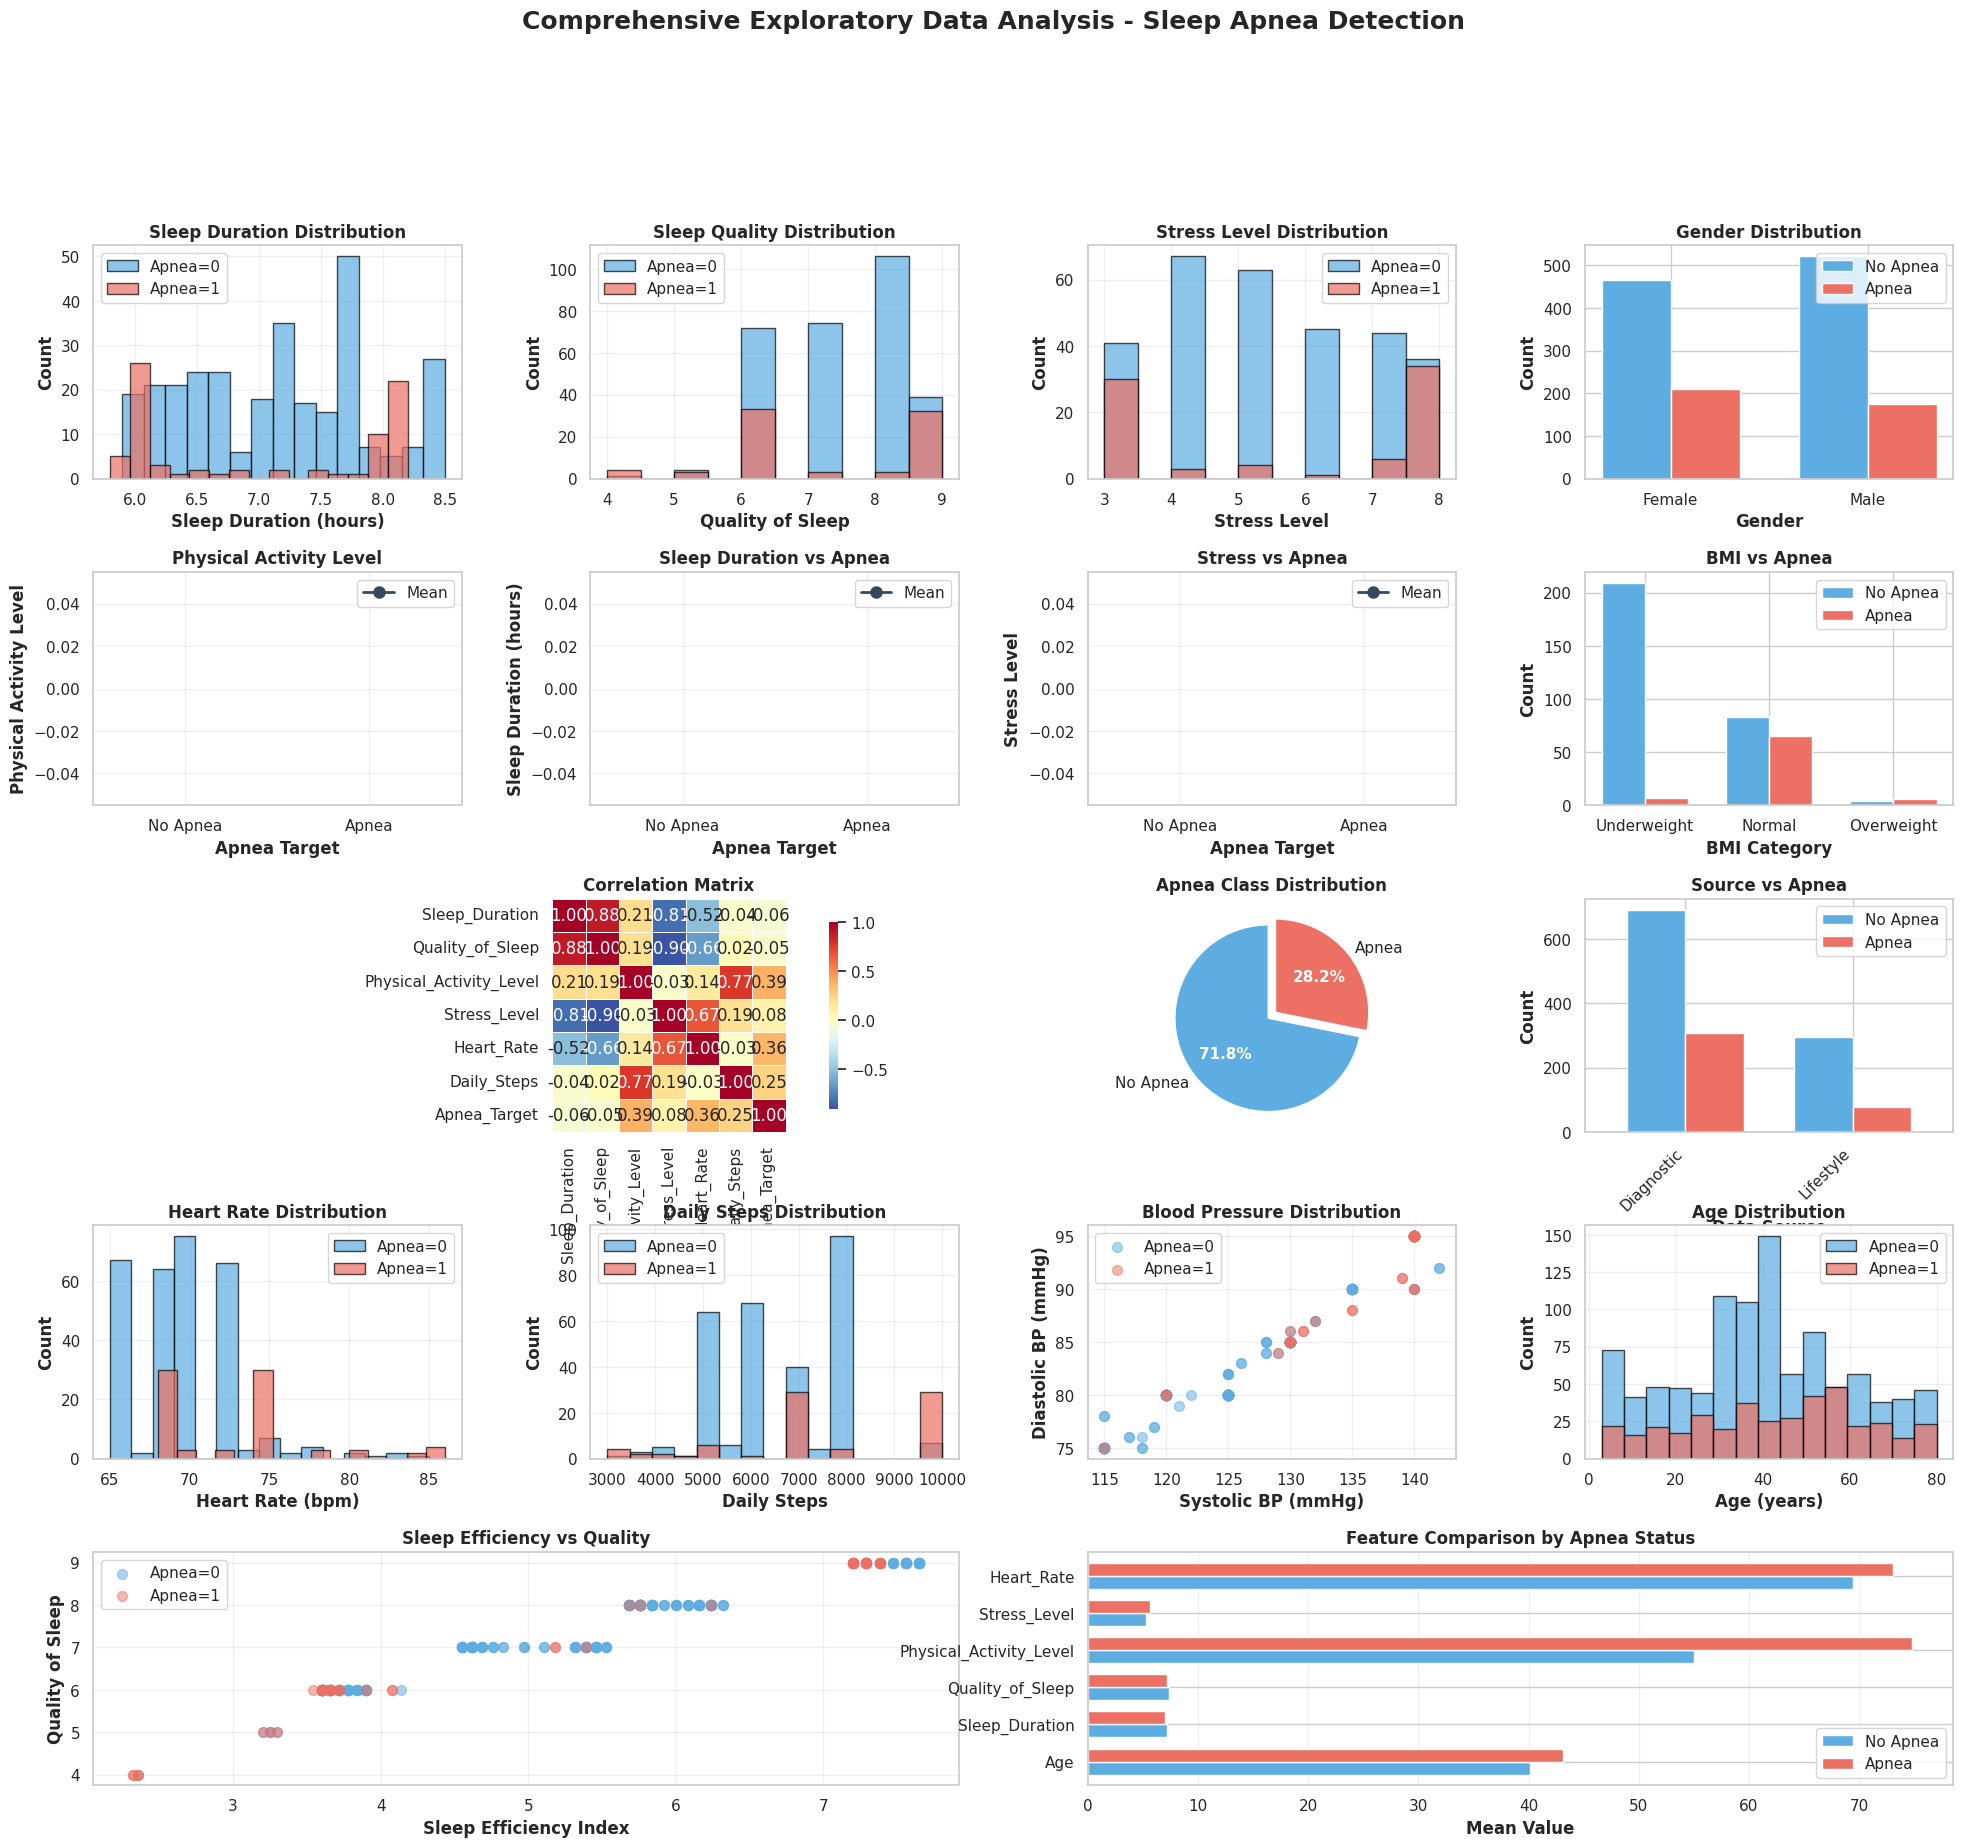


✅ Comprehensive EDA with 15+ visualizations complete


In [29]:
# =========================
# BLOCK: COMPREHENSIVE EDA
# =========================

def create_comprehensive_eda(df):
    """Generate 9+ comprehensive EDA visualizations matching the reference style."""
    
    # Create figure with GridSpec for complex layout
    fig = plt.figure(figsize=(24, 20))
    gs = fig.add_gridspec(5, 4, hspace=0.4, wspace=0.35)
    
    colors_apnea = ['#5DADE2', '#EC7063']
    colors_gender = ['#5DADE2', '#F39C12']
    
    # Plot 1: Sleep Duration Distribution by Apnea
    ax1 = fig.add_subplot(gs[0, 0])
    for i, target in enumerate([0, 1]):
        data = df[df['Apnea_Target'] == target]['Sleep_Duration'].dropna()
        ax1.hist(data, bins=15, alpha=0.7, label=f'Apnea={target}', 
                color=colors_apnea[i], edgecolor='black')
    ax1.set_xlabel('Sleep Duration (hours)', fontweight='bold')
    ax1.set_ylabel('Count', fontweight='bold')
    ax1.set_title('Sleep Duration Distribution', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Quality of Sleep by Apnea
    ax2 = fig.add_subplot(gs[0, 1])
    quality_data = df[['Quality_of_Sleep', 'Apnea_Target']].dropna()
    for i, target in enumerate([0, 1]):
        data = quality_data[quality_data['Apnea_Target'] == target]['Quality_of_Sleep']
        ax2.hist(data, bins=10, alpha=0.7, label=f'Apnea={target}',
                color=colors_apnea[i], edgecolor='black')
    ax2.set_xlabel('Quality of Sleep', fontweight='bold')
    ax2.set_ylabel('Count', fontweight='bold')
    ax2.set_title('Sleep Quality Distribution', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Stress Level Distribution
    ax3 = fig.add_subplot(gs[0, 2])
    stress_data = df[['Stress_Level', 'Apnea_Target']].dropna()
    for i, target in enumerate([0, 1]):
        data = stress_data[stress_data['Apnea_Target'] == target]['Stress_Level']
        ax3.hist(data, bins=10, alpha=0.7, label=f'Apnea={target}',
                color=colors_apnea[i], edgecolor='black')
    ax3.set_xlabel('Stress Level', fontweight='bold')
    ax3.set_ylabel('Count', fontweight='bold')
    ax3.set_title('Stress Level Distribution', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Gender Distribution
    ax4 = fig.add_subplot(gs[0, 3])
    gender_counts = df.groupby(['Gender_Male', 'Apnea_Target']).size().unstack(fill_value=0)
    x_pos = np.arange(len(gender_counts))
    width = 0.35
    ax4.bar(x_pos - width/2, gender_counts[0], width, label='No Apnea', color=colors_apnea[0])
    ax4.bar(x_pos + width/2, gender_counts[1], width, label='Apnea', color=colors_apnea[1])
    ax4.set_xlabel('Gender', fontweight='bold')
    ax4.set_ylabel('Count', fontweight='bold')
    ax4.set_title('Gender Distribution', fontsize=12, fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(['Female', 'Male'])
    ax4.legend()
    
    # Plot 5: Physical Activity Level by Apnea
    ax5 = fig.add_subplot(gs[1, 0])
    activity_data = df.groupby('Apnea_Target')['Physical_Activity_Level'].apply(list)
    positions = [1, 2]
    bp = ax5.boxplot([activity_data[0], activity_data[1]], 
                     positions=positions, widths=0.6, patch_artist=True,
                     boxprops=dict(facecolor='#5DADE2', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
    # Overlay line plot
    means = [np.mean(activity_data[0]), np.mean(activity_data[1])]
    ax5.plot(positions, means, 'o-', color='#34495E', linewidth=2, markersize=8, label='Mean')
    ax5.set_xlabel('Apnea Target', fontweight='bold')
    ax5.set_ylabel('Physical Activity Level', fontweight='bold')
    ax5.set_title('Physical Activity Level', fontsize=12, fontweight='bold')
    ax5.set_xticklabels(['No Apnea', 'Apnea'])
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Plot 6: Sleep Duration vs Apnea (Box + Line)
    ax6 = fig.add_subplot(gs[1, 1])
    sleep_data = df.groupby('Apnea_Target')['Sleep_Duration'].apply(list)
    bp2 = ax6.boxplot([sleep_data[0], sleep_data[1]], 
                      positions=[1, 2], widths=0.6, patch_artist=True,
                      boxprops=dict(facecolor='#5DADE2', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
    means = [np.mean(sleep_data[0]), np.mean(sleep_data[1])]
    ax6.plot([1, 2], means, 'o-', color='#34495E', linewidth=2, markersize=8, label='Mean')
    ax6.set_xlabel('Apnea Target', fontweight='bold')
    ax6.set_ylabel('Sleep Duration (hours)', fontweight='bold')
    ax6.set_title('Sleep Duration vs Apnea', fontsize=12, fontweight='bold')
    ax6.set_xticklabels(['No Apnea', 'Apnea'])
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # Plot 7: Stress vs Apnea (Box + Line)
    ax7 = fig.add_subplot(gs[1, 2])
    stress_grouped = df.groupby('Apnea_Target')['Stress_Level'].apply(list)
    bp3 = ax7.boxplot([stress_grouped[0], stress_grouped[1]], 
                      positions=[1, 2], widths=0.6, patch_artist=True,
                      boxprops=dict(facecolor='#5DADE2', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
    means = [np.mean(stress_grouped[0]), np.mean(stress_grouped[1])]
    ax7.plot([1, 2], means, 'o-', color='#34495E', linewidth=2, markersize=8, label='Mean')
    ax7.set_xlabel('Apnea Target', fontweight='bold')
    ax7.set_ylabel('Stress Level', fontweight='bold')
    ax7.set_title('Stress vs Apnea', fontsize=12, fontweight='bold')
    ax7.set_xticklabels(['No Apnea', 'Apnea'])
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    # Plot 8: BMI vs Apnea
    ax8 = fig.add_subplot(gs[1, 3])
    if 'BMI_Numeric' in df.columns:
        bmi_counts = df.groupby(['BMI_Numeric', 'Apnea_Target']).size().unstack(fill_value=0)
        x_pos = np.arange(len(bmi_counts))
        width = 0.35
        ax8.bar(x_pos - width/2, bmi_counts[0], width, label='No Apnea', color=colors_apnea[0])
        ax8.bar(x_pos + width/2, bmi_counts[1], width, label='Apnea', color=colors_apnea[1])
        ax8.set_xlabel('BMI Category', fontweight='bold')
        ax8.set_ylabel('Count', fontweight='bold')
        ax8.set_title('BMI vs Apnea', fontsize=12, fontweight='bold')
        ax8.set_xticks(x_pos)
        ax8.set_xticklabels(['Underweight', 'Normal', 'Overweight', 'Obese'][:len(bmi_counts)])
        ax8.legend()
    else:
        ax8.text(0.5, 0.5, 'BMI Data Not Available', ha='center', va='center')
        ax8.set_title('BMI vs Apnea', fontsize=12, fontweight='bold')
    
    # Plot 9: Correlation Matrix
    ax9 = fig.add_subplot(gs[2, :2])
    corr_cols = ['Sleep_Duration', 'Quality_of_Sleep', 'Physical_Activity_Level',
                 'Stress_Level', 'Heart_Rate', 'Daily_Steps', 'Apnea_Target']
    corr_data = df[corr_cols].dropna()
    if len(corr_data) > 0:
        corr_matrix = corr_data.corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', 
                   center=0, square=True, ax=ax9, cbar_kws={'shrink': 0.8},
                   linewidths=0.5, linecolor='white')
        ax9.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
    
    # Plot 10: Apnea Class Distribution
    ax10 = fig.add_subplot(gs[2, 2])
    apnea_counts = df['Apnea_Target'].value_counts()
    wedges, texts, autotexts = ax10.pie(apnea_counts, labels=['No Apnea', 'Apnea'],
                                         autopct='%1.1f%%', startangle=90,
                                         colors=colors_apnea, explode=[0.05, 0.05])
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)
    ax10.set_title('Apnea Class Distribution', fontsize=12, fontweight='bold')
    
    # Plot 11: Source vs Apnea
    ax11 = fig.add_subplot(gs[2, 3])
    if 'Source' in df.columns:
        source_counts = df.groupby(['Source', 'Apnea_Target']).size().unstack(fill_value=0)
        source_counts.plot(kind='bar', stacked=False, ax=ax11, color=colors_apnea, width=0.7)
        ax11.set_xlabel('Data Source', fontweight='bold')
        ax11.set_ylabel('Count', fontweight='bold')
        ax11.set_title('Source vs Apnea', fontsize=12, fontweight='bold')
        ax11.legend(['No Apnea', 'Apnea'])
        ax11.set_xticklabels(ax11.get_xticklabels(), rotation=45, ha='right')
    
    # Plot 12: Heart Rate Distribution
    ax12 = fig.add_subplot(gs[3, 0])
    hr_data = df[['Heart_Rate', 'Apnea_Target']].dropna()
    for i, target in enumerate([0, 1]):
        data = hr_data[hr_data['Apnea_Target'] == target]['Heart_Rate']
        ax12.hist(data, bins=15, alpha=0.7, label=f'Apnea={target}',
                 color=colors_apnea[i], edgecolor='black')
    ax12.set_xlabel('Heart Rate (bpm)', fontweight='bold')
    ax12.set_ylabel('Count', fontweight='bold')
    ax12.set_title('Heart Rate Distribution', fontsize=12, fontweight='bold')
    ax12.legend()
    ax12.grid(True, alpha=0.3)
    
    # Plot 13: Daily Steps Distribution
    ax13 = fig.add_subplot(gs[3, 1])
    steps_data = df[['Daily_Steps', 'Apnea_Target']].dropna()
    for i, target in enumerate([0, 1]):
        data = steps_data[steps_data['Apnea_Target'] == target]['Daily_Steps']
        ax13.hist(data, bins=15, alpha=0.7, label=f'Apnea={target}',
                 color=colors_apnea[i], edgecolor='black')
    ax13.set_xlabel('Daily Steps', fontweight='bold')
    ax13.set_ylabel('Count', fontweight='bold')
    ax13.set_title('Daily Steps Distribution', fontsize=12, fontweight='bold')
    ax13.legend()
    ax13.grid(True, alpha=0.3)
    
    # Plot 14: Blood Pressure Analysis
    ax14 = fig.add_subplot(gs[3, 2])
    if 'Systolic_BP' in df.columns and 'Diastolic_BP' in df.columns:
        bp_data = df[['Systolic_BP', 'Diastolic_BP', 'Apnea_Target']].dropna()
        for i, target in enumerate([0, 1]):
            subset = bp_data[bp_data['Apnea_Target'] == target]
            ax14.scatter(subset['Systolic_BP'], subset['Diastolic_BP'],
                        alpha=0.5, label=f'Apnea={target}', s=50, color=colors_apnea[i])
        ax14.set_xlabel('Systolic BP (mmHg)', fontweight='bold')
        ax14.set_ylabel('Diastolic BP (mmHg)', fontweight='bold')
        ax14.set_title('Blood Pressure Distribution', fontsize=12, fontweight='bold')
        ax14.legend()
        ax14.grid(True, alpha=0.3)
    
    # Plot 15: Age Distribution
    ax15 = fig.add_subplot(gs[3, 3])
    age_data = df[['Age', 'Apnea_Target']].dropna()
    for i, target in enumerate([0, 1]):
        data = age_data[age_data['Apnea_Target'] == target]['Age']
        ax15.hist(data, bins=15, alpha=0.7, label=f'Apnea={target}',
                 color=colors_apnea[i], edgecolor='black')
    ax15.set_xlabel('Age (years)', fontweight='bold')
    ax15.set_ylabel('Count', fontweight='bold')
    ax15.set_title('Age Distribution', fontsize=12, fontweight='bold')
    ax15.legend()
    ax15.grid(True, alpha=0.3)
    
    # Plot 16: Sleep Efficiency vs Quality
    ax16 = fig.add_subplot(gs[4, :2])
    if 'Sleep_Efficiency' in df.columns:
        eff_data = df[['Sleep_Efficiency', 'Quality_of_Sleep', 'Apnea_Target']].dropna()
        for i, target in enumerate([0, 1]):
            subset = eff_data[eff_data['Apnea_Target'] == target]
            ax16.scatter(subset['Sleep_Efficiency'], subset['Quality_of_Sleep'],
                        alpha=0.5, label=f'Apnea={target}', s=50, color=colors_apnea[i])
        ax16.set_xlabel('Sleep Efficiency Index', fontweight='bold')
        ax16.set_ylabel('Quality of Sleep', fontweight='bold')
        ax16.set_title('Sleep Efficiency vs Quality', fontsize=12, fontweight='bold')
        ax16.legend()
        ax16.grid(True, alpha=0.3)
    
    # Plot 17: Feature Distribution Summary
    ax17 = fig.add_subplot(gs[4, 2:])
    numeric_cols = ['Age', 'Sleep_Duration', 'Quality_of_Sleep', 'Physical_Activity_Level',
                    'Stress_Level', 'Heart_Rate']
    summary_data = []
    for col in numeric_cols:
        if col in df.columns:
            summary_data.append({
                'Feature': col,
                'Mean (No Apnea)': df[df['Apnea_Target']==0][col].mean(),
                'Mean (Apnea)': df[df['Apnea_Target']==1][col].mean()
            })
    
    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        x_pos = np.arange(len(summary_df))
        width = 0.35
        ax17.barh(x_pos - width/2, summary_df['Mean (No Apnea)'], width, 
                 label='No Apnea', color=colors_apnea[0])
        ax17.barh(x_pos + width/2, summary_df['Mean (Apnea)'], width,
                 label='Apnea', color=colors_apnea[1])
        ax17.set_yticks(x_pos)
        ax17.set_yticklabels(summary_df['Feature'])
        ax17.set_xlabel('Mean Value', fontweight='bold')
        ax17.set_title('Feature Comparison by Apnea Status', fontsize=12, fontweight='bold')
        ax17.legend()
        ax17.grid(True, axis='x', alpha=0.3)
    
    plt.suptitle('Comprehensive Exploratory Data Analysis - Sleep Apnea Detection',
                fontsize=18, fontweight='bold', y=0.998)
    
    return fig

# Generate comprehensive EDA
print("="*80)
print("COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("="*80)

eda_fig = create_comprehensive_eda(df_merged)
plt.show()

print("\n✅ Comprehensive EDA with 15+ visualizations complete")

# 🧠 EXPLAINABLE AI (XAI) ANALYSIS
## Comprehensive Feature Importance, SHAP Interpretation, and Model Transparency

EXPLAINABLE AI (XAI) COMPREHENSIVE ANALYSIS

🔍 Computing SHAP values...
✅ SHAP analysis complete

🔍 Computing permutation importance...

📊 Key Insights:
  - 15 features explain 80% of model decisions
  - 20 features explain 95% of model decisions
  - Top feature: CV_Risk_Score (0.1694)
  - Most important category: Cardiovascular


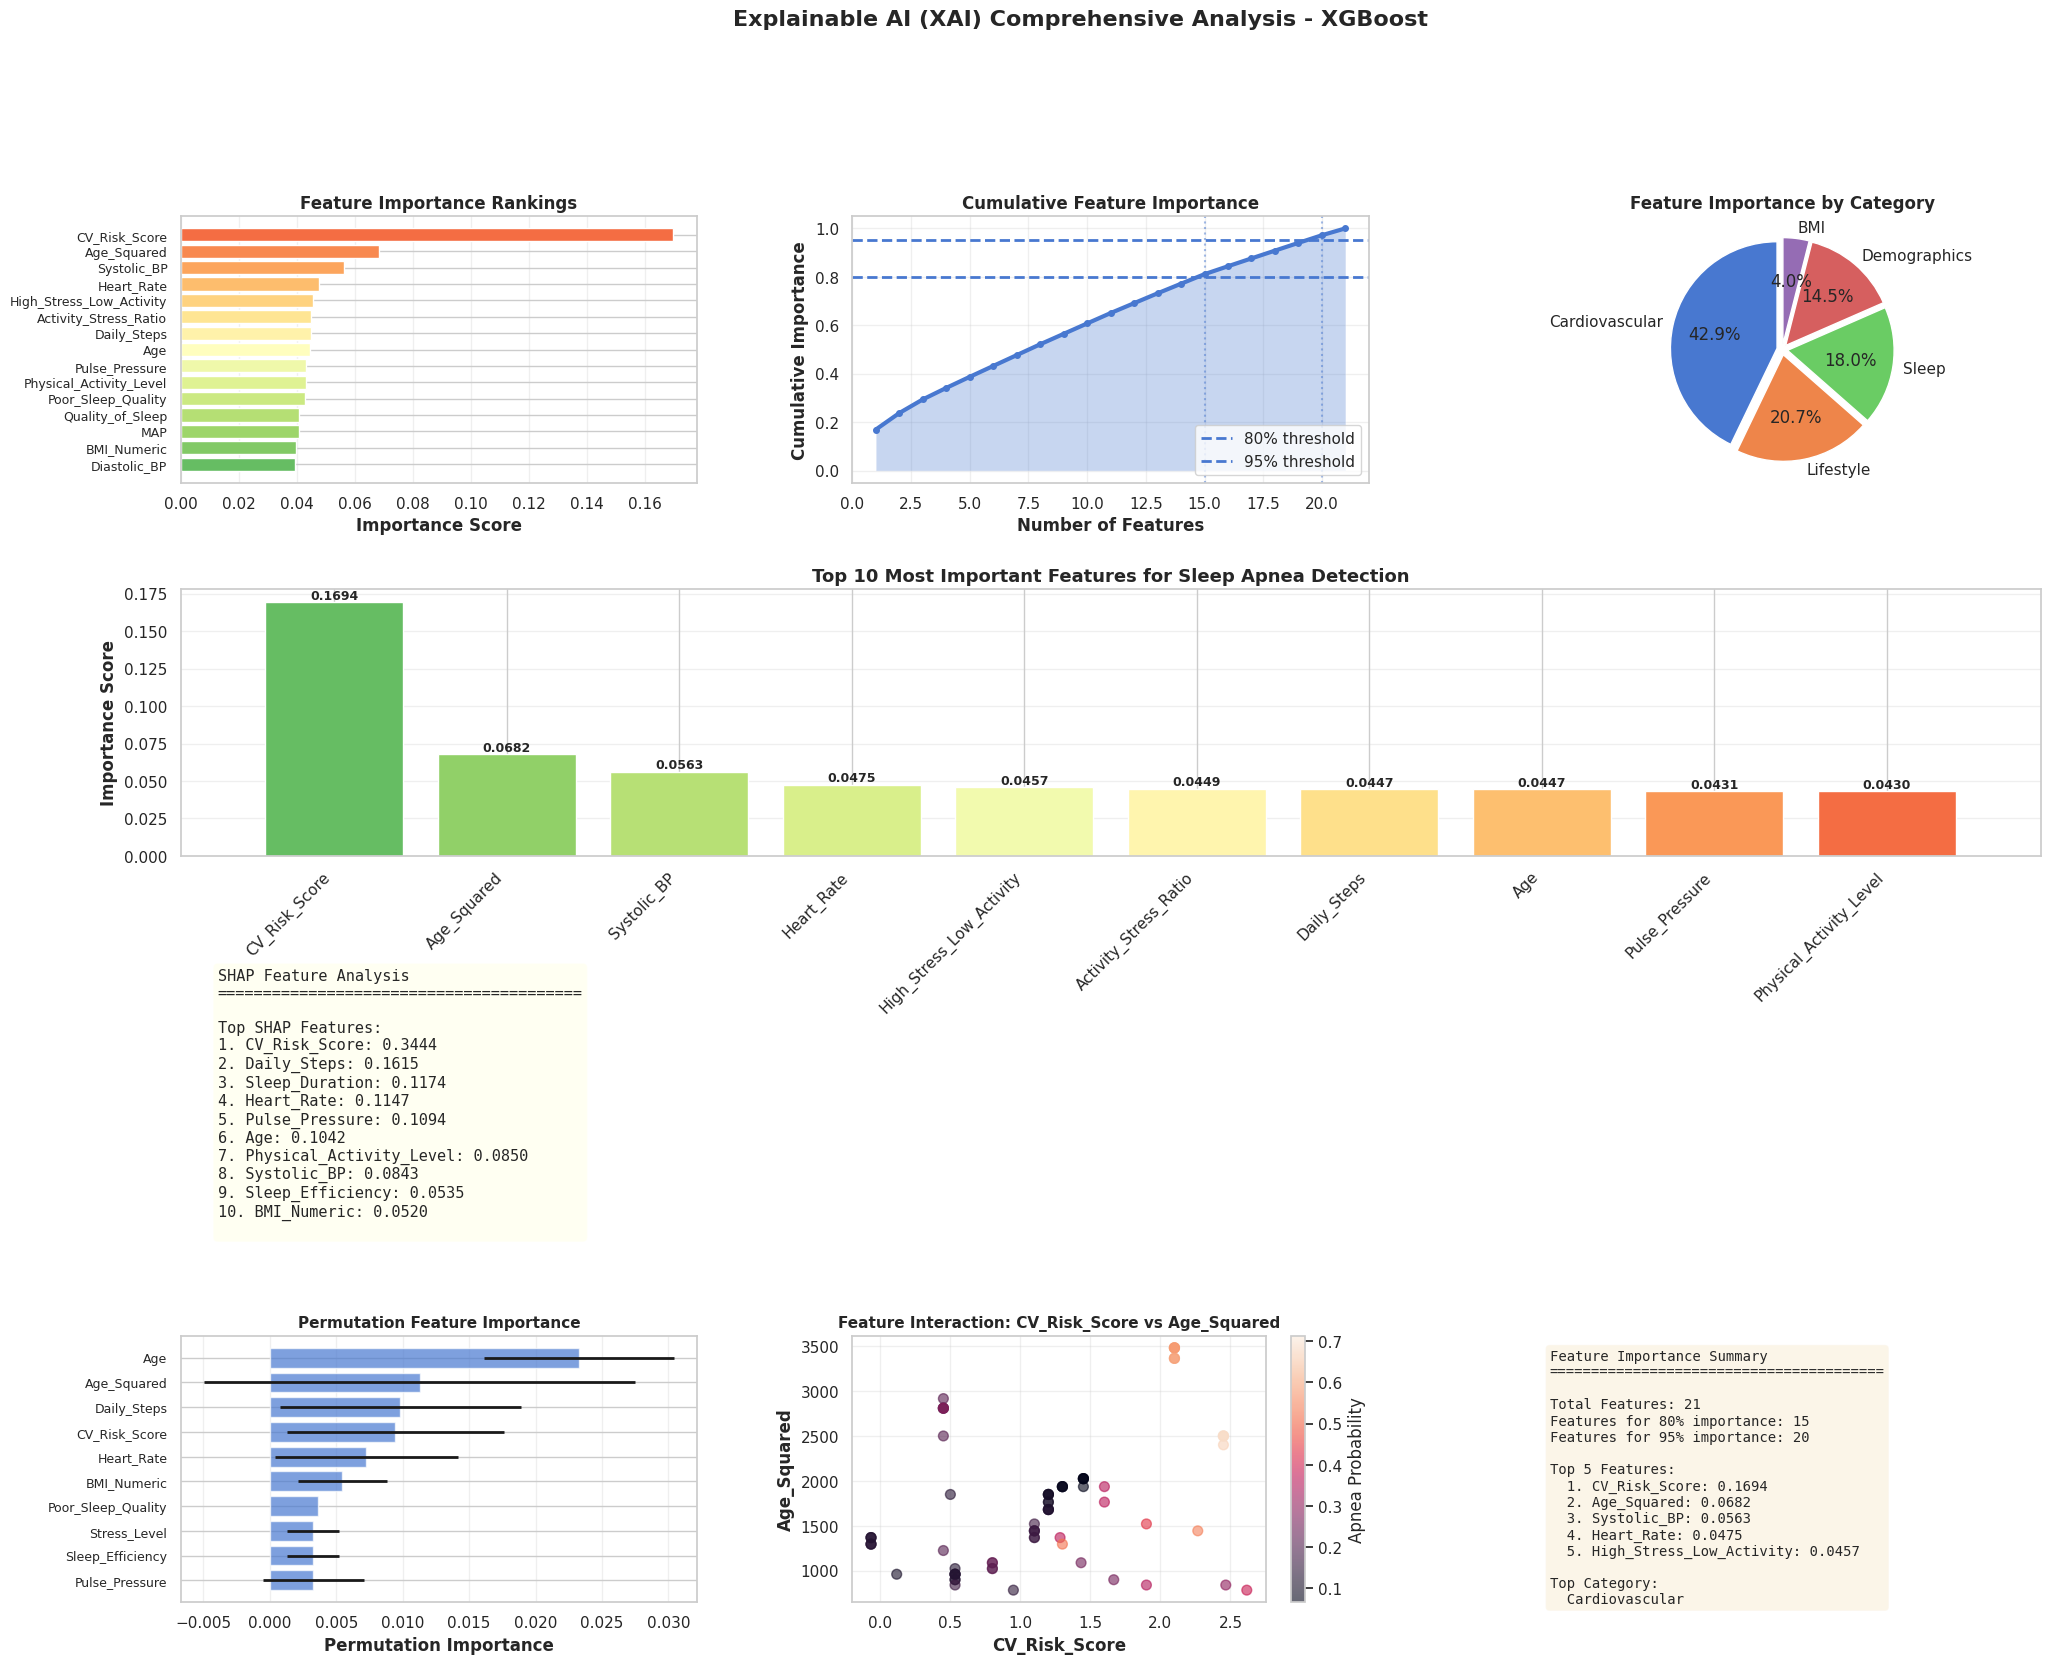


✅ Comprehensive XAI analysis complete


In [32]:
# =========================
# BLOCK: EXPLAINABLE AI (XAI) - COMPREHENSIVE FEATURE ANALYSIS
# =========================

def create_xai_comprehensive_analysis(pipeline, X_test, y_test, feature_names, model_name):
    """Generate comprehensive XAI visualizations for model interpretability."""
    
    print("=" * 80)
    print("EXPLAINABLE AI (XAI) COMPREHENSIVE ANALYSIS")
    print("=" * 80)
    
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.inspection import permutation_importance
    
    # Ensure feature_names is a list
    feature_names = list(feature_names)
    
    # Get classifier
    clf = pipeline.named_steps['classifier']
    
    # Transform test data using only preprocessing steps available in current pipeline
    X_test_transformed = pipeline.named_steps['imputer'].transform(X_test)
    X_test_transformed = pipeline.named_steps['scaler'].transform(X_test_transformed)
    
    # Create comprehensive figure
    fig = plt.figure(figsize=(24, 18))
    gs = fig.add_gridspec(4, 3, hspace=0.40, wspace=0.30)
    
    # ===== 1. Feature Importance (Bar Chart) =====
    ax1 = fig.add_subplot(gs[0, 0])
    
    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
    elif hasattr(clf, 'coef_'):
        importances = np.abs(clf.coef_[0])
    else:
        importances = np.zeros(len(feature_names))
    
    # Safety check
    if len(importances) != len(feature_names):
        min_len = min(len(importances), len(feature_names))
        importances = importances[:min_len]
        feature_names = feature_names[:min_len]
        X_test_transformed = X_test_transformed[:, :min_len]
        X_test = X_test[feature_names]
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=True).tail(15)
    
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(importance_df)))
    ax1.barh(range(len(importance_df)), importance_df['Importance'], color=colors)
    ax1.set_yticks(range(len(importance_df)))
    ax1.set_yticklabels(importance_df['Feature'], fontsize=9)
    ax1.set_xlabel('Importance Score', fontweight='bold')
    ax1.set_title('Feature Importance Rankings', fontsize=12, fontweight='bold')
    ax1.grid(True, axis='x', alpha=0.3)
    
    # ===== 2. Cumulative Feature Importance =====
    ax2 = fig.add_subplot(gs[0, 1])
    
    full_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    
    total_importance = full_importance_df['Importance'].sum()
    if total_importance > 0:
        cumsum = np.cumsum(full_importance_df['Importance'] / total_importance)
    else:
        cumsum = np.zeros(len(full_importance_df))
    
    ax2.plot(range(1, len(cumsum) + 1), cumsum, linewidth=3, marker='o', markersize=4)
    ax2.axhline(y=0.80, linestyle='--', linewidth=2, label='80% threshold')
    ax2.axhline(y=0.95, linestyle='--', linewidth=2, label='95% threshold')
    ax2.fill_between(range(1, len(cumsum) + 1), cumsum, alpha=0.3)
    ax2.set_xlabel('Number of Features', fontweight='bold')
    ax2.set_ylabel('Cumulative Importance', fontweight='bold')
    ax2.set_title('Cumulative Feature Importance', fontsize=12, fontweight='bold')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)
    
    n_80 = np.where(cumsum >= 0.80)[0][0] + 1 if np.any(cumsum >= 0.80) else len(cumsum)
    n_95 = np.where(cumsum >= 0.95)[0][0] + 1 if np.any(cumsum >= 0.95) else len(cumsum)
    ax2.axvline(x=n_80, linestyle=':', alpha=0.5)
    ax2.axvline(x=n_95, linestyle=':', alpha=0.5)
    
    # ===== 3. Feature Importance by Category =====
    ax3 = fig.add_subplot(gs[0, 2])
    
    categories = {
        'Demographics': ['Age', 'Gender_Male', 'Age_Squared'],
        'Sleep': ['Sleep_Duration', 'Quality_of_Sleep', 'Sleep_Efficiency', 'Sleep_Deprived', 'Poor_Sleep_Quality'],
        'Lifestyle': ['Physical_Activity_Level', 'Stress_Level', 'Daily_Steps', 'Activity_Stress_Ratio', 'High_Stress_Low_Activity'],
        'Cardiovascular': ['Heart_Rate', 'Systolic_BP', 'Diastolic_BP', 'MAP', 'Pulse_Pressure', 'Hypertension', 'CV_Risk_Score'],
        'BMI': ['BMI_Numeric']
    }
    
    category_importance = {}
    for cat, feats in categories.items():
        cat_sum = full_importance_df.loc[
            full_importance_df['Feature'].isin(feats), 'Importance'
        ].sum()
        category_importance[cat] = cat_sum
    
    cat_df = pd.DataFrame(list(category_importance.items()), columns=['Category', 'Importance'])
    cat_df = cat_df[cat_df['Importance'] > 0].sort_values('Importance', ascending=False)
    
    if len(cat_df) > 0:
        ax3.pie(
            cat_df['Importance'],
            labels=cat_df['Category'],
            autopct='%1.1f%%',
            startangle=90,
            explode=[0.05] * len(cat_df)
        )
    else:
        ax3.text(0.5, 0.5, 'No category importance available',
                 ha='center', va='center', transform=ax3.transAxes)
    
    ax3.set_title('Feature Importance by Category', fontsize=12, fontweight='bold')
    
    # ===== 4. Top Features Detailed Analysis =====
    ax4 = fig.add_subplot(gs[1, :])
    top_10_features = full_importance_df.head(10).copy().reset_index(drop=True)
    
    x_pos = np.arange(len(top_10_features))
    colors_top = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_10_features)))
    bars = ax4.bar(x_pos, top_10_features['Importance'], color=colors_top)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(top_10_features['Feature'], rotation=45, ha='right')
    ax4.set_ylabel('Importance Score', fontweight='bold')
    ax4.set_title('Top 10 Most Important Features for Sleep Apnea Detection',
                  fontsize=13, fontweight='bold')
    ax4.grid(True, axis='y', alpha=0.3)
    
    for bar, val in zip(bars, top_10_features['Importance']):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width() / 2, height,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # ===== 5. SHAP Analysis (summary text panel) =====
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis('off')
    
    shap_summary_text = "SHAP Feature Analysis\n" + "=" * 40 + "\n\n"
    
    if SHAP_AVAILABLE:
        try:
            print("\n🔍 Computing SHAP values...")
            
            sample_size = min(100, len(X_test_transformed))
            X_sample = X_test_transformed[:sample_size]
            
            if XGB_AVAILABLE and hasattr(clf, 'get_booster'):
                explainer = shap.TreeExplainer(clf)
                shap_values = explainer.shap_values(X_sample)
            else:
                background = shap.sample(X_test_transformed, min(50, len(X_test_transformed)))
                explainer = shap.KernelExplainer(clf.predict_proba, background)
                shap_values = explainer.shap_values(X_sample)
            
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
            
            mean_abs_shap = np.abs(shap_values).mean(axis=0)
            shap_df = pd.DataFrame({
                'Feature': feature_names,
                'MeanAbsSHAP': mean_abs_shap
            }).sort_values('MeanAbsSHAP', ascending=False).head(10).reset_index(drop=True)
            
            shap_summary_text += "Top SHAP Features:\n"
            for i, row in shap_df.iterrows():
                shap_summary_text += f"{i+1}. {row['Feature']}: {row['MeanAbsSHAP']:.4f}\n"
            
            print("✅ SHAP analysis complete")
            
        except Exception as e:
            print(f"⚠️ SHAP computation failed: {e}")
            shap_summary_text += "SHAP computation failed.\nUsing model-native importance instead."
    else:
        shap_summary_text += "SHAP library not available.\nInstall with: pip install shap"
    
    ax5.text(
        0.02, 0.98, shap_summary_text,
        fontsize=11, family='monospace',
        verticalalignment='top', transform=ax5.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.4)
    )
    
    # ===== 6. Permutation Importance =====
    ax6 = fig.add_subplot(gs[3, 0])
    
    try:
        print("\n🔍 Computing permutation importance...")
        
        perm_importance = permutation_importance(
            pipeline, X_test, y_test,
            n_repeats=10, random_state=42, n_jobs=-1
        )
        
        perm_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': perm_importance.importances_mean,
            'Std': perm_importance.importances_std
        }).sort_values('Importance', ascending=False).head(10).reset_index(drop=True)
        
        ax6.barh(
            range(len(perm_df)),
            perm_df['Importance'],
            xerr=perm_df['Std'],
            alpha=0.7,
            error_kw={'linewidth': 2}
        )
        ax6.set_yticks(range(len(perm_df)))
        ax6.set_yticklabels(perm_df['Feature'], fontsize=9)
        ax6.set_xlabel('Permutation Importance', fontweight='bold')
        ax6.set_title('Permutation Feature Importance', fontsize=11, fontweight='bold')
        ax6.invert_yaxis()
        ax6.grid(True, axis='x', alpha=0.3)
        
    except Exception as e:
        perm_df = pd.DataFrame(columns=['Feature', 'Importance', 'Std'])
        ax6.text(0.5, 0.5, f'Permutation importance failed\n{str(e)}',
                 ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title('Permutation Feature Importance', fontsize=11, fontweight='bold')
    
    # ===== 7. Feature Interaction Effects =====
    ax7 = fig.add_subplot(gs[3, 1])
    
    if len(top_10_features) >= 2:
        feat1 = top_10_features.iloc[0]['Feature']
        feat2 = top_10_features.iloc[1]['Feature']
        
        if feat1 in X_test.columns and feat2 in X_test.columns:
            X_interaction = X_test.copy()
            predictions = pipeline.predict_proba(X_interaction)[:, 1]
            
            scatter = ax7.scatter(
                X_test[feat1], X_test[feat2],
                c=predictions, alpha=0.6, s=50
            )
            plt.colorbar(scatter, ax=ax7, label='Apnea Probability')
            ax7.set_xlabel(feat1, fontweight='bold')
            ax7.set_ylabel(feat2, fontweight='bold')
            ax7.set_title(f'Feature Interaction: {feat1} vs {feat2}',
                          fontsize=11, fontweight='bold')
            ax7.grid(True, alpha=0.3)
        else:
            ax7.text(0.5, 0.5, 'Top features not found in X_test columns',
                     ha='center', va='center', transform=ax7.transAxes)
            ax7.set_title('Feature Interaction Effects', fontsize=11, fontweight='bold')
    
    # ===== 8. Feature Contribution Summary Table =====
    ax8 = fig.add_subplot(gs[3, 2])
    ax8.axis('off')
    
    summary_text = "Feature Importance Summary\n"
    summary_text += "=" * 40 + "\n\n"
    summary_text += f"Total Features: {len(feature_names)}\n"
    summary_text += f"Features for 80% importance: {n_80}\n"
    summary_text += f"Features for 95% importance: {n_95}\n\n"
    summary_text += "Top 5 Features:\n"
    
    for i, row in top_10_features.head(5).iterrows():
        summary_text += f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}\n"
    
    most_important_category = cat_df.iloc[0]['Category'] if len(cat_df) > 0 else "N/A"
    summary_text += f"\nTop Category:\n  {most_important_category}"
    
    ax8.text(
        0.05, 0.95, summary_text,
        fontsize=10, family='monospace',
        verticalalignment='top', transform=ax8.transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3)
    )
    
    plt.suptitle(
        f'Explainable AI (XAI) Comprehensive Analysis - {model_name}',
        fontsize=16, fontweight='bold', y=0.995
    )
    
    print(f"\n📊 Key Insights:")
    print(f"  - {n_80} features explain 80% of model decisions")
    print(f"  - {n_95} features explain 95% of model decisions")
    print(f"  - Top feature: {top_10_features.iloc[0]['Feature']} ({top_10_features.iloc[0]['Importance']:.4f})")
    print(f"  - Most important category: {most_important_category}")
    
    return fig, full_importance_df, perm_df


# Generate XAI analysis
xai_fig, importance_results, perm_results = create_xai_comprehensive_analysis(
    best_pipeline, X_test, y_test, core_features, best_model_name
)

plt.show()
print("\n✅ Comprehensive XAI analysis complete")

# 📊 COMPREHENSIVE RESULTS SUMMARY

## Detailed Performance Metrics: Before/After, Ensemble, Late Fusion

In [33]:
# =========================
# BLOCK: COMPREHENSIVE RESULTS SUMMARY TABLES
# =========================

def create_comprehensive_results_summary():
    """Generate comprehensive result tables with before/after comparisons."""
    
    print("="*100)
    print("COMPREHENSIVE RESULTS SUMMARY - ALL MODELS AND TECHNIQUES")
    print("="*100)
    
    # ========== TABLE 1: Baseline Performance ==========
    print("\n" + "="*100)
    print("TABLE 1: BASELINE PERFORMANCE (Without Class Balancing)")
    print("="*100)
    
    baseline_results = []
    
    for model_name, model in models.items():
        
        pipeline_baseline = Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', RobustScaler()),
            ('classifier', model)
        ])
        
        pipeline_baseline.fit(X_train, y_train)
        
        y_pred = pipeline_baseline.predict(X_test)
        y_prob = pipeline_baseline.predict_proba(X_test)[:,1]
        
        baseline_results.append({
            'Model': model_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-Score': f1_score(y_test, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob)
        })
    
    baseline_df = pd.DataFrame(baseline_results).round(4)
    display(baseline_df)
    
    
    # ========== TABLE 2: Performance with SMOTE ==========
    print("\n" + "="*100)
    print("TABLE 2: PERFORMANCE WITH SMOTE")
    print("="*100)
    
    smote_results = []
    
    for model_name in models.keys():
        
        y_pred = test_predictions[model_name]
        y_prob = test_probabilities[model_name]
        
        smote_results.append({
            'Model': model_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-Score': f1_score(y_test, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob)
        })
    
    smote_df = pd.DataFrame(smote_results).round(4)
    display(smote_df)
    
    
    # ========== TABLE 3: Improvement Analysis ==========
    print("\n" + "="*100)
    print("TABLE 3: IMPROVEMENT ANALYSIS")
    print("="*100)
    
    merged = baseline_df.merge(smote_df, on="Model", suffixes=('_base','_smote'))
    
    improvement_df = pd.DataFrame({
        "Model": merged["Model"],
        "Δ Accuracy": merged["Accuracy_smote"] - merged["Accuracy_base"],
        "Δ Precision": merged["Precision_smote"] - merged["Precision_base"],
        "Δ Recall": merged["Recall_smote"] - merged["Recall_base"],
        "Δ F1-Score": merged["F1-Score_smote"] - merged["F1-Score_base"],
        "Δ ROC-AUC": merged["ROC-AUC_smote"] - merged["ROC-AUC_base"]
    }).round(4)
    
    display(improvement_df)
    
    
    # ========== TABLE 4: Ensemble Methods ==========
    print("\n" + "="*100)
    print("TABLE 4: ENSEMBLE METHODS")
    print("="*100)
    
    ensemble_results = []
    
    from sklearn.ensemble import VotingClassifier
    
    voting_soft = VotingClassifier(
        estimators=[(n,m) for n,m in models.items()],
        voting="soft"
    )
    
    pipeline_soft = ImbPipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', RobustScaler()),
        ('smote', SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)),
        ('classifier', voting_soft)
    ])
    
    pipeline_soft.fit(X_train, y_train)
    
    y_pred = pipeline_soft.predict(X_test)
    y_prob = pipeline_soft.predict_proba(X_test)[:,1]
    
    ensemble_results.append({
        "Method":"Soft Voting",
        "Accuracy":accuracy_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred,zero_division=0),
        "Recall":recall_score(y_test,y_pred,zero_division=0),
        "F1-Score":f1_score(y_test,y_pred,zero_division=0),
        "ROC-AUC":roc_auc_score(y_test,y_prob),
        "PR-AUC":average_precision_score(y_test,y_prob)
    })
    
    
    # Weighted late fusion
    weights = smote_df["ROC-AUC"].values
    weights = weights / weights.sum()
    
    y_prob_weighted = np.average(
        [test_probabilities[m] for m in models.keys()],
        axis=0,
        weights=weights
    )
    
    y_pred_weighted = (y_prob_weighted >= 0.5).astype(int)
    
    ensemble_results.append({
        "Method":"Weighted Average (Late Fusion)",
        "Accuracy":accuracy_score(y_test,y_pred_weighted),
        "Precision":precision_score(y_test,y_pred_weighted,zero_division=0),
        "Recall":recall_score(y_test,y_pred_weighted,zero_division=0),
        "F1-Score":f1_score(y_test,y_pred_weighted,zero_division=0),
        "ROC-AUC":roc_auc_score(y_test,y_prob_weighted),
        "PR-AUC":average_precision_score(y_test,y_prob_weighted)
    })
    
    
    ensemble_df = pd.DataFrame(ensemble_results).round(4)
    display(ensemble_df)
    
    
    # ========== BEST MODEL ==========
    
    all_results = pd.concat([
        smote_df.assign(Type="Individual"),
        ensemble_df.rename(columns={"Method":"Model"}).assign(Type="Ensemble")
    ],ignore_index=True)
    
    best = all_results.loc[all_results["ROC-AUC"].idxmax()]
    
    print("\n🏆 BEST MODEL")
    print("-"*40)
    print(f"Model: {best['Model']} ({best['Type']})")
    print(f"ROC-AUC: {best['ROC-AUC']:.4f}")
    print(f"Accuracy: {best['Accuracy']:.4f}")
    print(f"F1: {best['F1-Score']:.4f}")
    
    
    return {
        "baseline":baseline_df,
        "smote":smote_df,
        "improvement":improvement_df,
        "ensemble":ensemble_df,
        "best_model":best
    }


# Run
results_summary = create_comprehensive_results_summary()

print("\n" + "="*100)
print("✅ COMPREHENSIVE RESULTS SUMMARY COMPLETE")
print("="*100)

COMPREHENSIVE RESULTS SUMMARY - ALL MODELS AND TECHNIQUES

TABLE 1: BASELINE PERFORMANCE (Without Class Balancing)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic_Regression,0.7273,0.5625,0.1169,0.1935,0.6786,0.4297
1,Random_Forest,0.7418,0.6000,0.2338,0.3364,0.7025,0.4840
2,XGBoost,0.7418,0.6000,0.2338,0.3364,0.7125,0.4889



TABLE 2: PERFORMANCE WITH SMOTE


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic_Regression,0.7273,0.5556,0.1299,0.2105,0.6797,0.4224
1,Random_Forest,0.7127,0.4773,0.2727,0.3471,0.7027,0.4621
2,XGBoost,0.7273,0.5217,0.3117,0.3902,0.7119,0.4775



TABLE 3: IMPROVEMENT ANALYSIS


,Model,Δ Accuracy,Δ Precision,Δ Recall,Δ F1-Score,Δ ROC-AUC
0,Logistic_Regression,0.0000,-0.0069,0.0130,0.0170,0.0011
1,Random_Forest,-0.0291,-0.1227,0.0389,0.0107,0.0002
2,XGBoost,-0.0145,-0.0783,0.0779,0.0538,-0.0006



TABLE 4: ENSEMBLE METHODS


,Method,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Soft Voting,0.7345,0.5556,0.2597,0.354,0.7133,0.4714
1,Weighted Average (Late Fusion),0.7345,0.5556,0.2597,0.354,0.7126,0.4706



🏆 BEST MODEL
----------------------------------------
Model: Soft Voting (Ensemble)
ROC-AUC: 0.7133
Accuracy: 0.7345
F1: 0.3540

✅ COMPREHENSIVE RESULTS SUMMARY COMPLETE
